# Background Stuff

In [ ]:
#Imports 
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
#from DiscEvolution.eos import LocallyIsothermalEOS  
#from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
#from DiscEvolution.disc import AccretionDisc
#from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.internal_photo import ConstantInternalPhotoevap
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from matplotlib import colors

# Increase resolution (DPI) for better quality
plt.rcParams['figure.dpi'] = 300 

In [2]:
#Initialized but value given in next cell
M_disk_0 = None
Rc = None
R_in = None
Mdot_0 = None
Mstar = None
Rstar = None
mu = None
# LBP surface density profile with gamma = 1: Sigma(r) = (M_disk / (2*pi*Rc*r)) * exp(-r/Rc)
def Sigma_LBP_1(r) -> float:
    val = (M_disk_0)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

def Temperature(r) -> float:
    T_0 = 150 * u.K 
    val  = T_0 * (r / (1.0 * u.AU))**(-1/2)
    if val.cgs.unit != u.K:
        print('Temperature error')
        return 0
    return val.cgs

def Omega(r) -> float:
    val = np.sqrt((const.G*Mstar)/(r**3))
    if (val.cgs.unit != (1 / u.s)): 
        print("Omega error")
        return 0
    return val.cgs

def c_s(r) -> float:
    val = np.sqrt((const.k_B*Temperature(r))/(mu*const.m_p))
    if (val.cgs.unit != (u.cm / u.s)): 
        print("c_s error")
        return 0
    return val.cgs

def H(r) -> float: 
    val = c_s(r)/Omega(r)
    if val.cgs.unit != (u.cm):
        print("H error")
        return 0
    return val.cgs

#Given Mdisk, Mdot(0), Rc -> Calculate alpha and Sigma0
def calculateAlpha() -> float:
    Rin_cgs = (R_in * u.AU).to(u.cm)               #cm
    Mdot_cgs = Mdot_0.to(u.g / u.s).value  # g/s
    M_disk_cgs = M_disk_0.cgs.value         #g
    cs_val = c_s(Rin_cgs).value                   # cm/s
    omega = Omega(Rin_cgs).value                   # 1/s
    Rc_cgs = Rc.cgs.value               #cm
    alpha = Mdot_cgs*((2*Rin_cgs.value*omega)/3) * (Rc_cgs/((cs_val**2) * M_disk_cgs))
    return alpha 

# Parameters

In [3]:
t_initial = 0.1 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 2.0 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.32 * u.solMass #High-mass
#Mdot_0 = 5E-8 * u.solMass / u.yr  #TODO
Rc = 91.0 * u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.2 * u.solMass
Rstar = 3.0 * u.solRad
Tstar = 4395.0 * u.K
mu = 2.33

psi = 10 #TODO
alpha_eff = 1e-3 # Drives the gas disk evolution
    
alpha_turb = alpha_eff / (1.0 + psi)   
alpha_wind = psi * alpha_turb          #Not used for calculations, just for prints

print(f"\nalpha_eff: {alpha_eff:.0e}")
print(f"alpha_turb: {alpha_turb:.0e}")
print(f"alpha_wind: {alpha_wind:.0e}")


alpha_eff: 1e-03
alpha_turb: 9e-05
alpha_wind: 9e-04


In [4]:
#Deadzone parameters
alpha_active = alpha_turb     
alpha_dead = 0.01 * alpha_turb  #TODO
dz_width_scaling = 1.0

R_dz_initial = 1.0e1 * u.AU
R_dz_min = 2.0 * u.AU

print(f"alpha_active: {alpha_active:.2e}")
print(f"alpha_dead: {alpha_dead:.2e}")
print(f"Transition width: {dz_width_scaling:.1f} * H")
print(f"Initial Deadzone Radius: {R_dz_initial:.1f}")
print(f"Mininum Deadzone Radius: {R_dz_min:.1f}")

def compute_R_dz(t_yr, R_dz_initial_AU, R_dz_min_AU, t_start_yr, t_final_yr) -> float: 
    """
    Moves Rdz linearly from initial to min over the disc lifetime.
    """

    disc_lifetime_yr = t_final_yr - t_start_yr
    distance = R_dz_initial_AU.value - R_dz_min_AU.value 
    velocity = distance / disc_lifetime_yr #Au/yr 
    t_rel = max(0.0, t_yr - t_start_yr)

    return max(R_dz_initial_AU.value - (velocity * t_rel), R_dz_min_AU.value) 

def compute_alpha_turb_array(disc, R_dz, alpha_dead, alpha_active, width_factor=1.0):
    """
    Creates a smooth alpha array that transitions at R_dz.
    Transitions in log-space to ensure smooth orders of magnitude.
    """

    log_a_dead = np.log10(alpha_dead)
    log_a_active = np.log10(alpha_active)

    # Find the exact scale height (H) at the deadzone boundary
    H_at_rdz = np.interp(R_dz, disc.R, disc.H) #np.interp looks at where R_dz falls inside disc.R and estimates the exact H there (scale height not aspect ratio)
    
    # Tanh transition: 0 in dead zone, 1 in active zone
    transition = 0.5 * (1.0 + np.tanh((disc.R - R_dz) / (width_factor * H_at_rdz)))
    
    # Blend in log space
    log_alpha_array = log_a_dead + transition * (log_a_active - log_a_dead)
    
    return 10**log_alpha_array

alpha_active: 9.09e-05
alpha_dead: 9.09e-07
Transition width: 1.0 * H
Initial Deadzone Radius: 10.0 AU
Mininum Deadzone Radius: 2.0 AU


In [5]:
# 1) Create grid
R_in = 0.1 #AU
R_out = 120.0  # AU
Ncells = 500
grid = Grid(R_in, R_out, Ncells, spacing='natural')

In [6]:
# 2) Create star
star = SimpleStar(M = Mstar.value ,R = Rstar.value, T_eff = Tstar.value, age = t_initial_yr)  #Msun, Rsun, K, yr

In [7]:
# 3) Create EOS 
eos = IrradiatedEOS(
    star,
    alpha_t=alpha_turb,   # Turbulent alpha
    Tc=10,                # External/nebular temperature floor (K)
    Tmax=1500,            # Maximum temperature cap (K)
    mu=mu,
    gamma=1.0,
    accrete=True,          # Include viscous heating from accretion
    kappa=Zhu2012
)

eos.set_grid(grid)

In [8]:
# 4) Create surface density array from LBP profile
R_centers = grid.Rc  # AU
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU).value for r in R_centers])

eos.update(0, Sigma_initial)

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:459: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


In [9]:
# 5) Create the disc with dust
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              # Initial dust-to-gas ratio
    Sigma=Sigma_initial,
    feedback=True,         # Dust affects gas dynamics
    f_ice=1,             # Ice fraction (affects fragmentation)
    uf_0=100,             # Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           # Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             # Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0) #This is to have the pebble size and stokes number correct at t=0

In [10]:
# 6) Set up viscous evolution
visc_evol = HybridWindModel(psi_DW=psi, lambda_DW=3, tol=0.5, boundary='power_law', in_bound='Mdot')
disc._gas = visc_evol #FIXES AN ERROR IN TORQUE CALCS

In [11]:
# 6.2) Add Chemistry
# Create chemistry solver
chem_model = EquilibriumCOChemOberg(fix_ratios=False, a=1e-5)

# Set solar abundances
X_solar = SimpleCOAtomAbund(disc.Ncells)
X_solar.set_solar_abundances()

# Iterate to convergence (ice fraction changes dust-to-gas ratio)
for i in range(10):
    chem = chem_model.equilibrium_chem(
        disc.T, 
        disc.midplane_gas_density,
        disc.dust_frac.sum(0), 
        X_solar
    )
    disc.initialize_dust_density(chem.ice.total_abund)

# Attach to disc
disc.chem = chem
disc.update_ices(disc.chem.ice)

drift = SingleFluidDrift(diffusion=None, settling=True)

driver = PlanetDiscDriver(
    disc, 
    gas=visc_evol, 
    dust=drift,
    chemistry=chem_model,  #Driver will handle updating chemistry for gas and ices
    t0=t_initial_code
)

In [12]:
# 6.3) Setup the deadzone and EOS overrides
alpha_turb_array = compute_alpha_turb_array(disc, compute_R_dz(t_initial_yr, R_dz_initial, R_dz_min, t_initial_yr, t_final_yr), alpha_dead, alpha_active, dz_width_scaling)

#Override alpha
eos._alpha = alpha_turb_array.copy()

#Recompute nu using the new alpha
cs_array = eos._f_cs(disc.R)            
H_array = eos._f_H(disc.R)
eos._nu = eos._alpha * cs_array * H_array

#Ensures update() uses a representative alpha value for heating calculations
eos._alpha_t = np.mean(eos._alpha)

#print(alpha_turb_array)

In [ ]:
# 7) Setup evolution 
# Check timestep size
run_start_yr = t_initial_yr
run_end_yr = t_final_yr
run_duration_yr = run_end_yr - run_start_yr

dt_max = visc_evol.max_timestep(disc) / yr_code
print(f"dt_max = {dt_max:.1f} years")
print(f"Estimated steps: {run_duration_yr/dt_max:.0f}")

# Output times (absolute years, matching driver.t timeline)
output_times_yr = np.linspace(run_start_yr, run_end_yr, 11)
output_times_code = output_times_yr * yr_code

# Snapshot offsets from t_initial
snapshot_offsets_yr = np.array([0.4e6,0.9e6,1.9e6])     ###HERE is where you tell which ones to plot/save (always plots tinitial)
snapshot_times_yr = run_start_yr + snapshot_offsets_yr
snapshot_times_code = snapshot_times_yr * yr_code

io = Event_Controller(save=output_times_code, snapshot=snapshot_times_code)

history = {'t_yr': [], 'Mtot': [], 'Rout': [], 'dt_yr': [], 'Rc': []}
snapshots = {'t_yr': [], 'Sigma_G': [], 'Sigma_D': [], 'dust_frac': [], 'St': [], 'grain_size': [], 'T': [], 'P': [], 'chem_ice': [], 'chem_gas': [], 'mid_gas_dens': [], 'rdz': [], 'alpha': [], 'H': []}

# t = t_initial history
dt_current = visc_evol.max_timestep(disc)
history['t_yr'].append(driver.t / yr_code)
history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))
history['Rout'].append(disc.Rout())
history['dt_yr'].append(dt_current / yr_code)
history['dt_yr'].append(disc.RC())

# t = t_initial snapshot
snapshots['t_yr'].append(driver.t / yr_code)
snapshots['Sigma_G'].append(disc.Sigma_G.copy())
snapshots['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy()) #Total dust Sigma, pebbles + grains
snapshots['dust_frac'].append(disc.dust_frac.sum(axis=0).copy()) #Total dust to gas ratio
snapshots['St'].append(disc.Stokes()[1].copy())  #Pebbles not small grains
snapshots['grain_size'].append(disc.grain_size[1].copy()) #Pebbles not small grains
snapshots['T'].append(disc.T.copy()) #Temp
snapshots['P'].append(disc.P.copy()) #Pressure
snapshots['chem_ice'].append(disc.chem.ice.data.copy())
snapshots['chem_gas'].append(disc.chem.gas.data.copy())
snapshots['mid_gas_dens'].append(disc.midplane_gas_density.copy())
snapshots['rdz'].append(R_dz_initial.value)
snapshots['alpha'].append(alpha_turb_array.copy())
snapshots['H'].append(disc.H.copy())

dt_max = 406.4 years
Estimated steps: 4675


In [ ]:
# 7.2) Setup torque maps

#Create M-R diagram space
mass_array = np.logspace(-2,3,Ncells) #Mearth required by compute_torque function
radius_array = disc.R #AU
R_grid, M_grid = np.meshgrid(radius_array, mass_array) #2D grid from two 1D arrays

#Storage array
torque_maps = {
    't_yr': snapshots['t_yr'].copy(),
    'maps': [],
    'R_grid': R_grid,
    'M_grid': M_grid
}

#Initial Torque map
TypeI = pf.TypeIMigration(disc) #Creates a Type I migration object from the disc object
Torque_map = np.zeros_like(R_grid) #initialize 2D grid with all values zero 

#Compute Torques
for i, Mp in enumerate(mass_array):
    #Pass Mp as an array of the same shape as radius_array
    Mp_array = np.ones_like(radius_array) * Mp #entire row with said mass value
    #Compute the total torque for said mass at each R 
    Torque_map[i, :] = TypeI.compute_torque_raw(radius_array, Mp_array)
    
torque_maps['maps'].append(Torque_map)

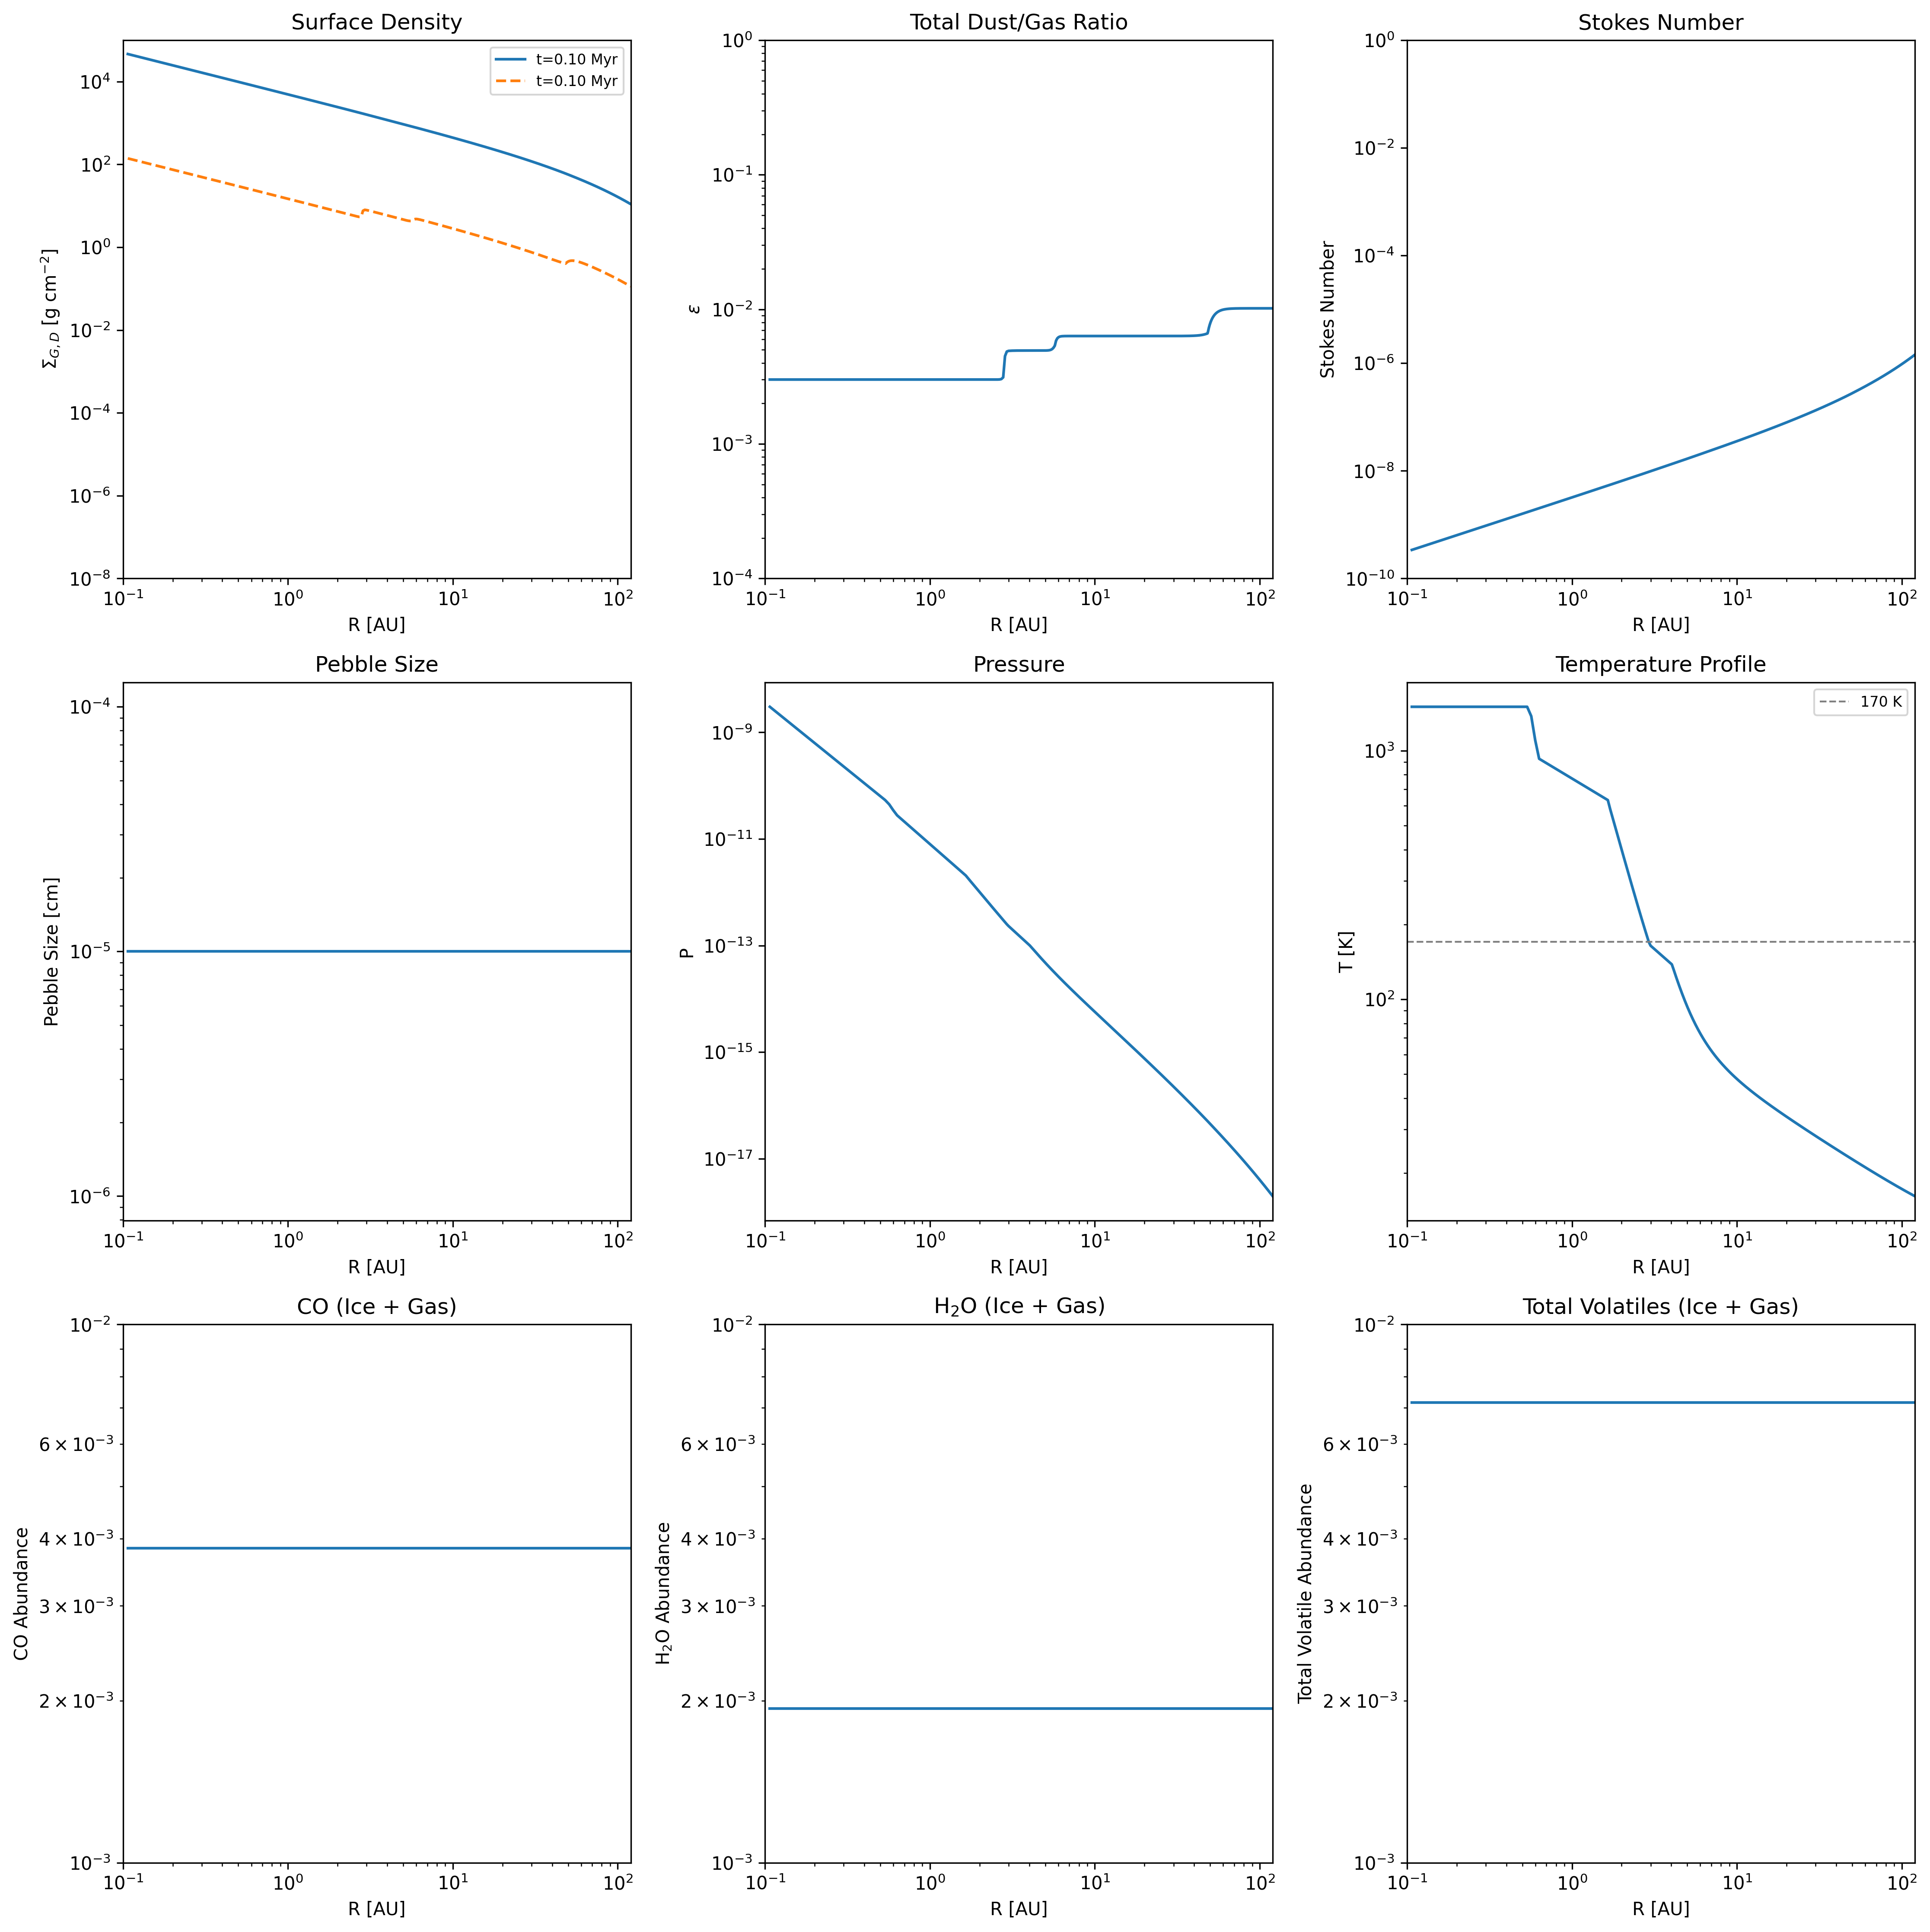


Chemistry species tracked: ['CO', 'CH4', 'CO2', 'H2O', 'C-grain', 'Si-grain']


In [15]:
#Plot the intial values
# Plot evolution results with dust properties and chemistry
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
lw = 1.5

# Get chemical species names and find indices
try:
    chem_species = disc.chem.ice.names
    idx_CO = chem_species.index('CO') if 'CO' in chem_species else None
    idx_H2O = chem_species.index('H2O') if 'H2O' in chem_species else None
    idx_CH4 = chem_species.index('CH4') if 'CH4' in chem_species else None
except (AttributeError, ValueError):
    idx_CO = idx_H2O = idx_CH4 = None

# 1. Surface density: Gas and Dust
ax = axes[0, 0]

ax.loglog(disc.R, snapshots['Sigma_G'][0], linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)
ax.loglog(disc.R, snapshots['Sigma_D'][0], linestyle='dashed', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)

ax.set_ylim(1e-8, 1e5)
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
ax.set_title('Surface Density')
ax.legend(fontsize=8)
ax.set_xlim(R_in, R_out)

# 2. Dust-to-gas ratio (epsilon)
ax = axes[0, 1]

ax.loglog(disc.R, snapshots['dust_frac'][0], linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)

ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\epsilon$')
ax.set_title('Total Dust/Gas Ratio')
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-4, 1e0)

# 3. Stokes number
ax = axes[0, 2]

ax.loglog(disc.R, snapshots['St'][0], linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)

ax.set_xlabel('R [AU]')
ax.set_ylabel('Stokes Number')
ax.set_title('Stokes Number')
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-10,1e0)

# 4. Pebble size
ax = axes[1, 0]

ax.loglog(disc.R, snapshots['grain_size'][0], linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)

ax.set_xlabel('R [AU]')
ax.set_ylabel('Pebble Size [cm]')
ax.set_title('Pebble Size')
ax.set_xlim(R_in, R_out)

# 5. Pressure
ax = axes[1, 1]
 
ax.loglog(disc.R, np.abs(snapshots['P'][0]), linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)

ax.set_xlabel('R [AU]')
ax.set_ylabel('P')
ax.set_title('Pressure')
ax.set_xlim(R_in, R_out)

# 6. Temperature profile
ax = axes[1, 2]

ax.loglog(disc.R, snapshots['T'][0], linestyle='solid', lw=lw)
ax.axhline(170, ls = 'dashed', label='170 K', color = 'gray', lw=1)

ax.set_xlabel('R [AU]')
ax.set_ylabel('T [K]')
ax.set_title('Temperature Profile')
ax.set_xlim(R_in, R_out)
ax.legend(fontsize=8)

# 7. CO abundance (ice + gas combined)
ax = axes[2, 0]

if idx_CO is not None:
    CO_total = snapshots['chem_ice'][0][idx_CO] + snapshots['chem_gas'][0][idx_CO]  # Sum of ice and gas
    ax.loglog(disc.R, CO_total, linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'CO Abundance')
    ax.set_title('CO (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'CO not found in chemistry', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('CO (Ice + Gas)')

# 8. H2O abundance (ice + gas combined)
ax = axes[2, 1]

if idx_H2O is not None:
    
    H2O_total = snapshots['chem_ice'][0][idx_H2O] + snapshots['chem_gas'][0][idx_H2O]  # Sum of ice and gas
    ax.loglog(disc.R, H2O_total, linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)
      
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'H$_2$O Abundance')
    ax.set_title(r'H$_2$O (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'H2O not found in chemistry', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(r'H$_2$O (Ice + Gas)')

# 9. Total volatile abundance (sum of volatile molecules, excluding grains)
ax = axes[2, 2]

if idx_CO is not None:
    # Sum all volatiles (exclude grain species which typically have 'grain' in name)
    volatile_ice = np.sum([snapshots['chem_ice'][0][j] for j in range(len(chem_species)) 
                            if 'grain' not in chem_species[j]], axis=0)
    volatile_gas = np.sum([snapshots['chem_gas'][0][j] for j in range(len(chem_species)) 
                            if 'grain' not in chem_species[j]], axis=0)
    volatile_total = volatile_ice + volatile_gas
    ax.loglog(disc.R, volatile_total, linestyle='solid', label=rf"t={snapshots['t_yr'][0]/1e6:.2f} Myr", lw=lw)
     
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'Total Volatile Abundance')
    ax.set_title('Total Volatiles (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'Chemistry data not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Total Volatiles (Ice + Gas)')

plt.tight_layout()
plt.show()

# Print chemistry species for reference
if idx_CO is not None:
    print(f"\nChemistry species tracked: {chem_species}")

# Evolution


In [ ]:
# 8) Evolve disc
pbar = tqdm(total=run_duration_yr,
             unit='yr', 
             desc='Evolving disc... ', 
            bar_format='{desc}: {percentage:.1f}%|{bar}| {n:.2e}/{total:.2e} yr {rate_fmt} [{elapsed}<{remaining}]')
last_elapsed_yr = 0.0
steps = 0
t_yr = driver.t / yr_code

while not io.finished():
    ti = io.next_event_time()

    while driver.t < ti:
        #Update the dead zone position for this time step
        current_R_dz = compute_R_dz(t_yr, R_dz_initial, R_dz_min, t_initial_yr, 1e6) #use 1e6 since we want it to hit 2AU at 1Myr not 2Myr
        #Update alpha array
        alpha_turb_array = compute_alpha_turb_array(disc, current_R_dz, alpha_dead, alpha_active, dz_width_scaling)
        
        #Override alpha
        eos._alpha = alpha_turb_array.copy()
        #Recompute nu using the new alpha
        cs_array = eos._f_cs(disc.R)            
        H_array = eos._f_H(disc.R)
        eos._nu = eos._alpha * cs_array * H_array
        #Ensures update() uses a representative alpha value for heating calculations
        eos._alpha_t = np.mean(eos._alpha)

        dt = driver(ti)
        steps += 1

        # pbar progress within the run window only
        t_yr = driver.t / yr_code
        elapsed_yr = max(0.0, t_yr - run_start_yr)
        pbar.update(elapsed_yr - last_elapsed_yr)
        last_elapsed_yr = elapsed_yr

    # Keep t_yr defined even if no integration step was taken in this event window
    t_yr = driver.t / yr_code

    # Store snapshots at snapshot times
    if io.check_event(driver.t, 'snapshot'):
        snapshots['t_yr'].append(t_yr)
        snapshots['Sigma_G'].append(disc.Sigma_G.copy())
        snapshots['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy()) #Total dust Sigma, pebbles + grains
        snapshots['dust_frac'].append(disc.dust_frac.sum(axis=0).copy()) #Total dust to gas ratio
        snapshots['St'].append(disc.Stokes()[1].copy()) #Pebbles not small grains
        snapshots['grain_size'].append(disc.grain_size[1].copy()) #Pebbles not small grains
        snapshots['T'].append(disc.T.copy()) #Temp
        snapshots['P'].append(disc.P.copy()) #Pressure
        snapshots['chem_ice'].append(disc.chem.ice.data.copy()) #ice chemistry
        snapshots['chem_gas'].append(disc.chem.gas.data.copy()) #gas chemistry
        snapshots['mid_gas_dens'].append(disc.midplane_gas_density.copy())
        snapshots['rdz'].append(current_R_dz)
        snapshots['alpha'].append(alpha_turb_array.copy())
        snapshots['H'].append(disc.H.copy())
    
        #Torque map data 
        TypeI = pf.TypeIMigration(disc) #Creates a Type I migration object from the disc object
        Torque_map = np.zeros_like(R_grid) #initialize 2D grid with all values zero 
        #Compute Torques
        for i, Mp in enumerate(mass_array):
            #Pass Mp as an array of the same shape as radius_array
            Mp_array = np.ones_like(radius_array) * Mp #entire row with said mass value
            #Compute the total torque for said mass at each R 
            Torque_map[i, :] = TypeI.compute_torque_raw(radius_array, Mp_array)
        torque_maps['maps'].append(Torque_map)

        io.pop_events(driver.t, 'snapshot')

    # Store at output times
    if io.check_event(driver.t, 'save'):
        dt_current = visc_evol.max_timestep(disc)
        history['t_yr'].append(t_yr)
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))
        history['Rout'].append(disc.Rout())
        history['dt_yr'].append(dt_current / yr_code)
        history['Rc'].append(disc.RC())
        io.pop_events(driver.t, 'save')

pbar.close()
print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")
print(f"Final disc outer radius: {disc.Rout():.2f} AU")
print(f"Average dt: {np.mean(history['dt_yr']):.1f} years")

Rout_initial = history['Rout'][0]
Rout_final = disc.Rout()  # or history['Rout'][-1]

print(f"Initial Rout: {Rout_initial:.2f} AU")
print(f"Final Rout:   {Rout_final:.2f} AU")
print(f"Delta Rout:   {Rout_final - Rout_initial:+.2f} AU")
print(f"Percent change: {(Rout_final / Rout_initial - 1)*100:+.2f}%")

print("Initial Rc (input):", Rc.value)
print("Initial Rout(thresh=1e-5):", history['Rout'][0])
print("Final   Rout(thresh=1e-5):", history['Rout'][-1])
print("Current fitted RC():", disc.RC())

Evolving disc... : 0.0%|          | 0.00e+00/1.90e+06 yr ?yr/s [00:00<?]

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/brent.py:101: RuntimeWarning: divide by zero encountered in divide
  -fcur*(fblk*dblk - fpre*dpre) /    # Extrapolate
/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/dust.py:435: RuntimeWarning: overflow encountered in exp
  amax = np.minimum(a0, a*np.exp(dt/t_grow))  # If dust grains start small (default) first have to grow)
/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/dust.py:435: RuntimeWarning: overflow encountered in multiply
  amax = np.minimum(a0, a*np.exp(dt/t_grow))  # If dust grains start small (default) first have to grow)



=== EVOLUTION COMPLETE ===
Total steps: 116629
Final time: 2.0e+06 years
Final mass: 2.209e-01 M_sun (94.4% of initial)
Final disc outer radius: 120.00 AU
Average dt: 117.9 years
Initial Rout: 120.00 AU
Final Rout:   120.00 AU
Delta Rout:   +0.00 AU
Percent change: +0.00%
Initial Rc (input): 91.0
Initial Rout(thresh=1e-5): 120.0
Final   Rout(thresh=1e-5): 120.0
Current fitted RC(): 83.92886226169722


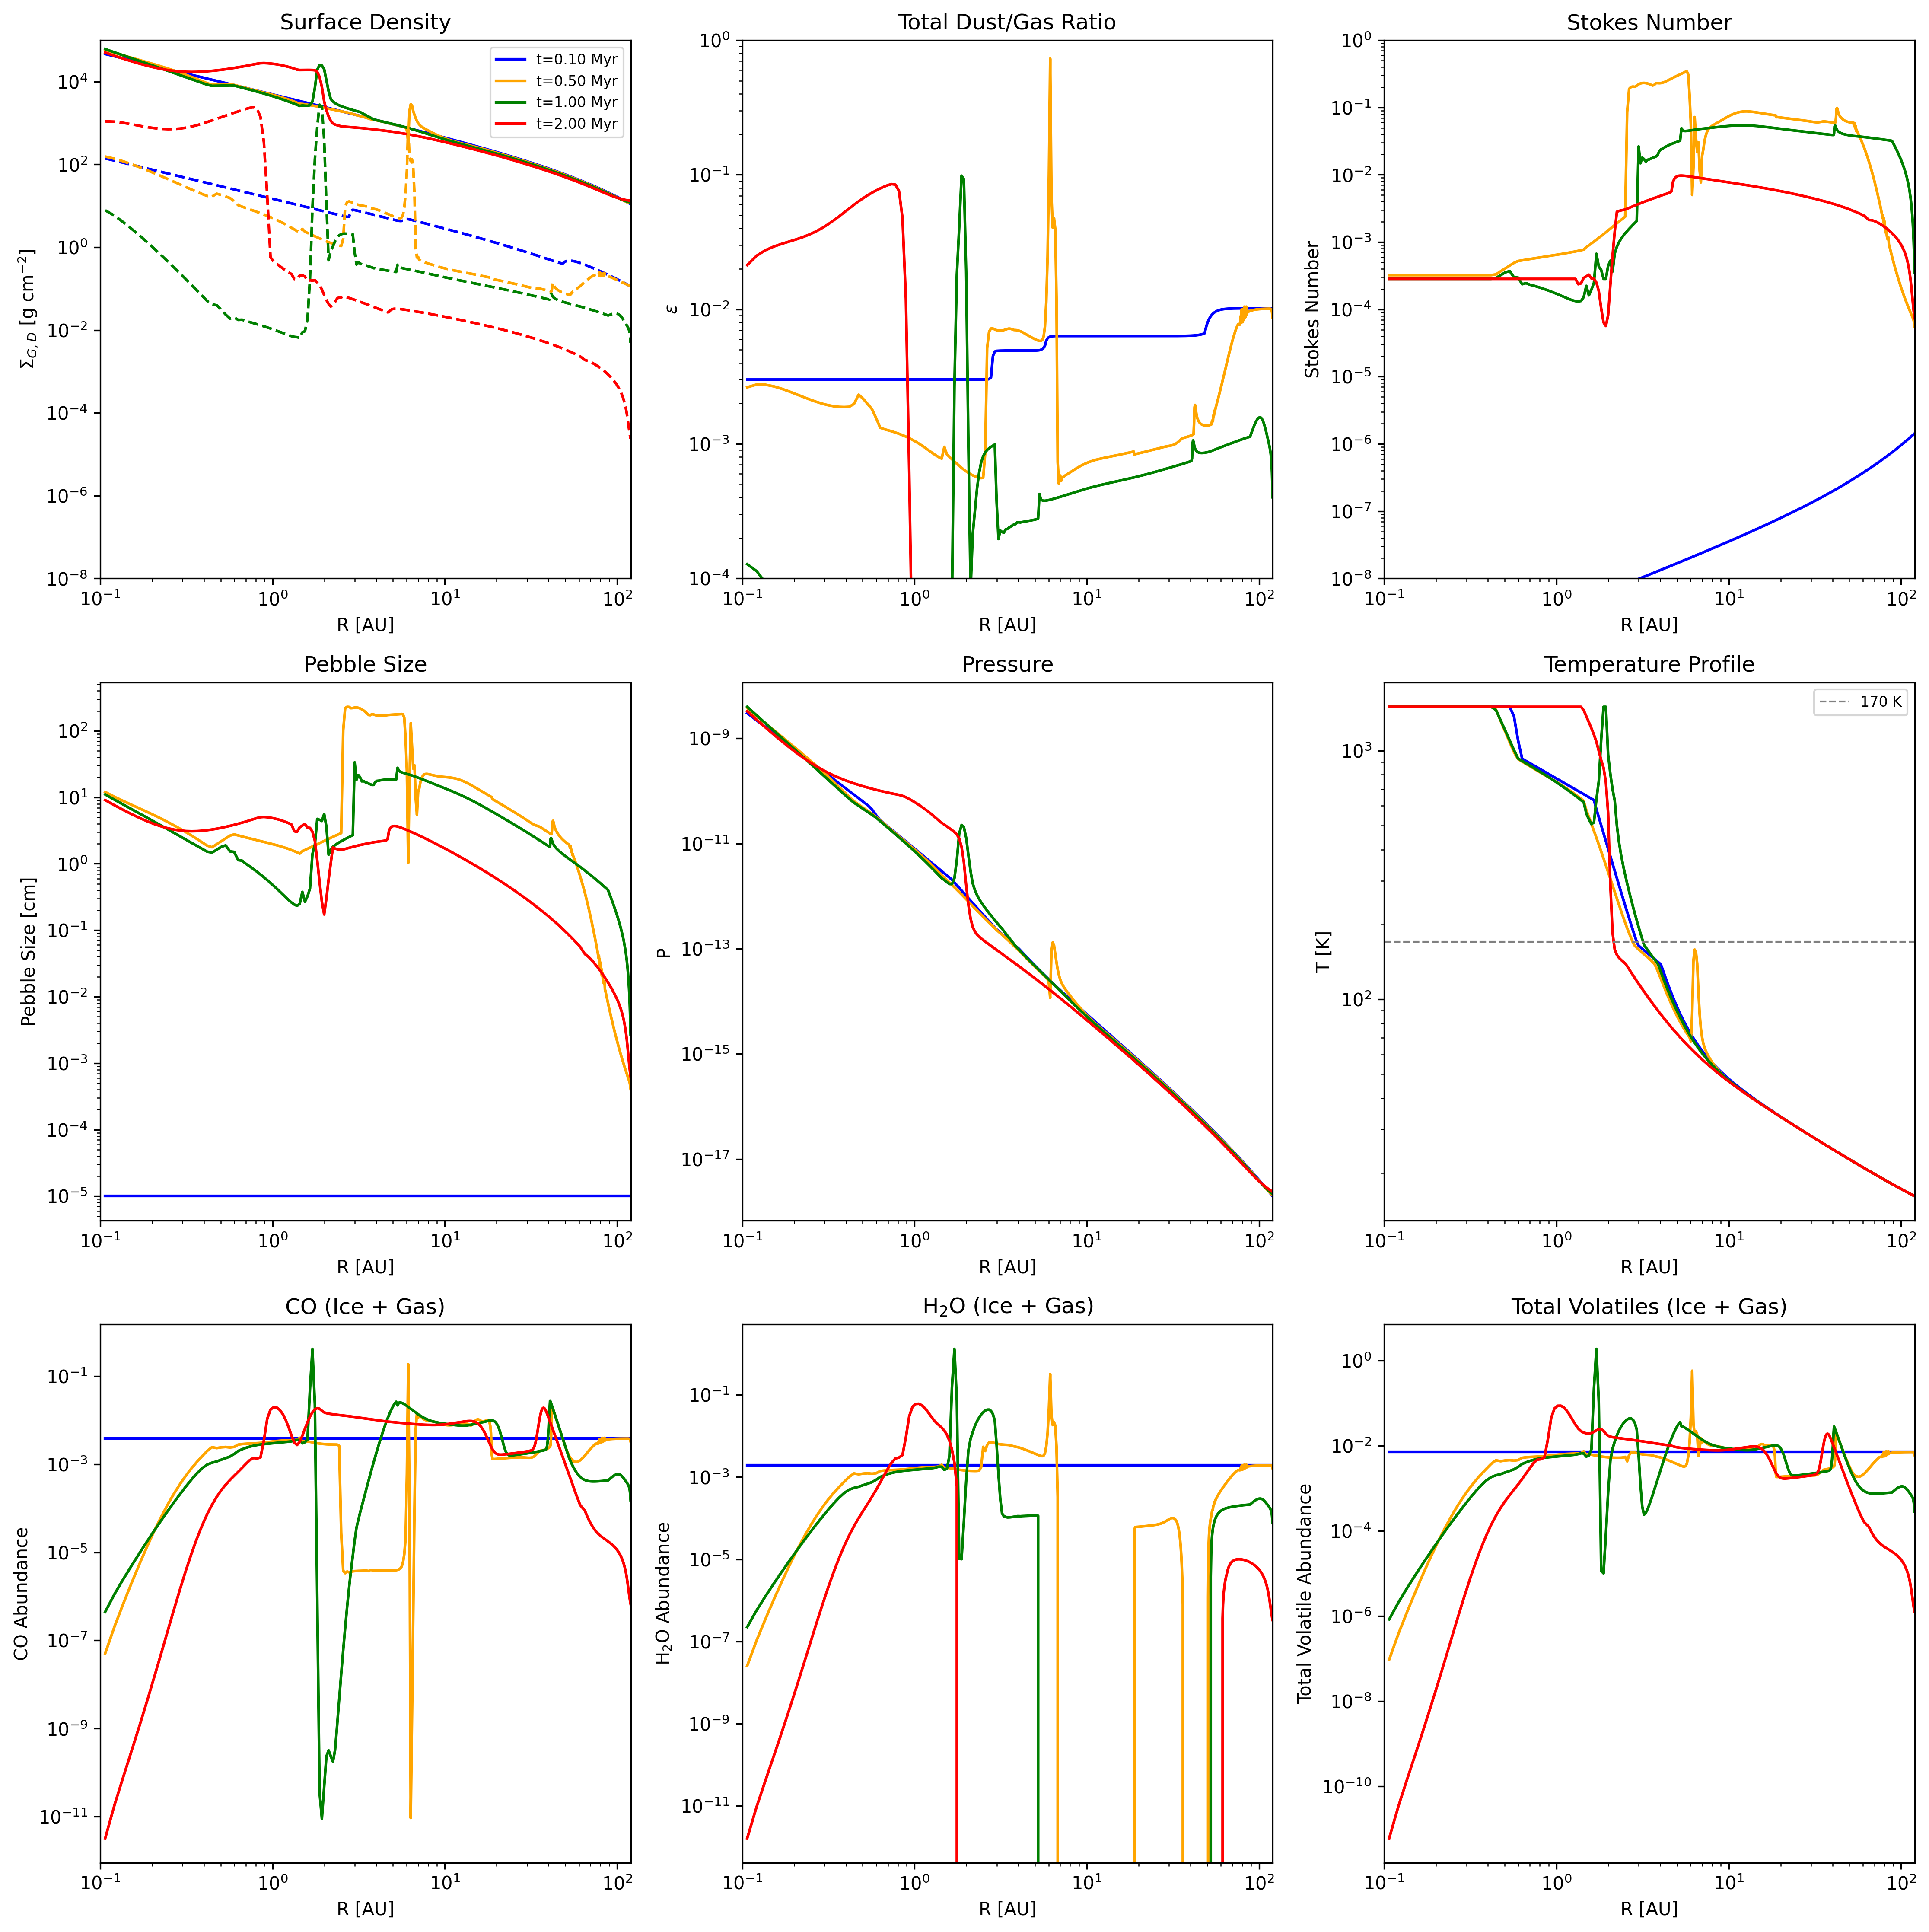


Chemistry species tracked: ['CO', 'CH4', 'CO2', 'H2O', 'C-grain', 'Si-grain']


In [17]:
# Plot evolution results with dust properties and chemistry
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
lw = 1.5

# Get chemical species names and find indices
try:
    chem_species = disc.chem.ice.names
    idx_CO = chem_species.index('CO') if 'CO' in chem_species else None
    idx_H2O = chem_species.index('H2O') if 'H2O' in chem_species else None
    idx_CH4 = chem_species.index('CH4') if 'CH4' in chem_species else None
except (AttributeError, ValueError):
    idx_CO = idx_H2O = idx_CH4 = None

# Color cycle for time snapshots
from cycler import cycler
c = ['blue','orange','g','r']
ax_prop_cycle = cycler(color=c)

# 1. Surface density: Gas and Dust
ax = axes[0, 0]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['Sigma_G']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

i = 0
for line in snapshots['Sigma_D']:
    ax.loglog(disc.R, line, linestyle='dashed', lw=lw)
    i += 1
ax.set_ylim(1e-8, 1e5)
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
ax.set_title('Surface Density')
ax.legend(fontsize=8)
ax.set_xlim(R_in, R_out)

# 2. Dust-to-gas ratio (epsilon)
ax = axes[0, 1]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['dust_frac']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\epsilon$')
ax.set_title('Total Dust/Gas Ratio')
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-4, 1e0)

# 3. Stokes number
ax = axes[0, 2]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['St']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel('Stokes Number')
ax.set_title('Stokes Number')
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-8, 1e0)

# 4. Pebble size
ax = axes[1, 0]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['grain_size']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel('Pebble Size [cm]')
ax.set_title('Pebble Size')
ax.set_xlim(R_in, R_out)

# 5. Pressure
ax = axes[1, 1]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['P']:
    ax.loglog(disc.R, np.abs(line), linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1
ax.set_xlabel('R [AU]')
ax.set_ylabel('P')
ax.set_title('Pressure')
ax.set_xlim(R_in, R_out)

# 6. Temperature profile
ax = axes[1, 2]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['T']:
    ax.loglog(disc.R, line, linestyle='solid', lw=lw)
    i += 1
ax.axhline(170, ls = 'dashed', label='170 K', color = 'gray', lw=1)

ax.set_xlabel('R [AU]')
ax.set_ylabel('T [K]')
ax.set_title('Temperature Profile')
ax.set_xlim(R_in, R_out)
ax.legend(fontsize=8)

# 7. CO abundance (ice + gas combined)
ax = axes[2, 0]
ax.set_prop_cycle(ax_prop_cycle)

if idx_CO is not None:
    i = 0
    for ice_data, gas_data in zip(snapshots['chem_ice'], snapshots['chem_gas']):
        CO_total = ice_data[idx_CO] + gas_data[idx_CO]  # Sum of ice and gas
        ax.loglog(disc.R, CO_total, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        i += 1
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'CO Abundance')
    ax.set_title('CO (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'CO not found in chemistry', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('CO (Ice + Gas)')

# 8. H2O abundance (ice + gas combined)
ax = axes[2, 1]
ax.set_prop_cycle(ax_prop_cycle)

if idx_H2O is not None:
    i = 0
    for ice_data, gas_data in zip(snapshots['chem_ice'], snapshots['chem_gas']):
        H2O_total = ice_data[idx_H2O] + gas_data[idx_H2O]  # Sum of ice and gas
        ax.loglog(disc.R, H2O_total, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        i += 1
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'H$_2$O Abundance')
    ax.set_title(r'H$_2$O (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'H2O not found in chemistry', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(r'H$_2$O (Ice + Gas)')

# 9. Total volatile abundance (sum of volatile molecules, excluding grains)
ax = axes[2, 2]
ax.set_prop_cycle(ax_prop_cycle)

if idx_CO is not None:
    i = 0
    for ice_data, gas_data in zip(snapshots['chem_ice'], snapshots['chem_gas']):
        # Sum all volatiles (exclude grain species which typically have 'grain' in name)
        volatile_ice = np.sum([ice_data[j] for j in range(len(chem_species)) 
                               if 'grain' not in chem_species[j]], axis=0)
        volatile_gas = np.sum([gas_data[j] for j in range(len(chem_species)) 
                               if 'grain' not in chem_species[j]], axis=0)
        volatile_total = volatile_ice + volatile_gas
        ax.loglog(disc.R, volatile_total, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        i += 1
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'Total Volatile Abundance')
    ax.set_title('Total Volatiles (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'Chemistry data not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Total Volatiles (Ice + Gas)')

plt.tight_layout()
plt.show()

# Print chemistry species for reference
if idx_CO is not None:
    print(f"\nChemistry species tracked: {chem_species}")

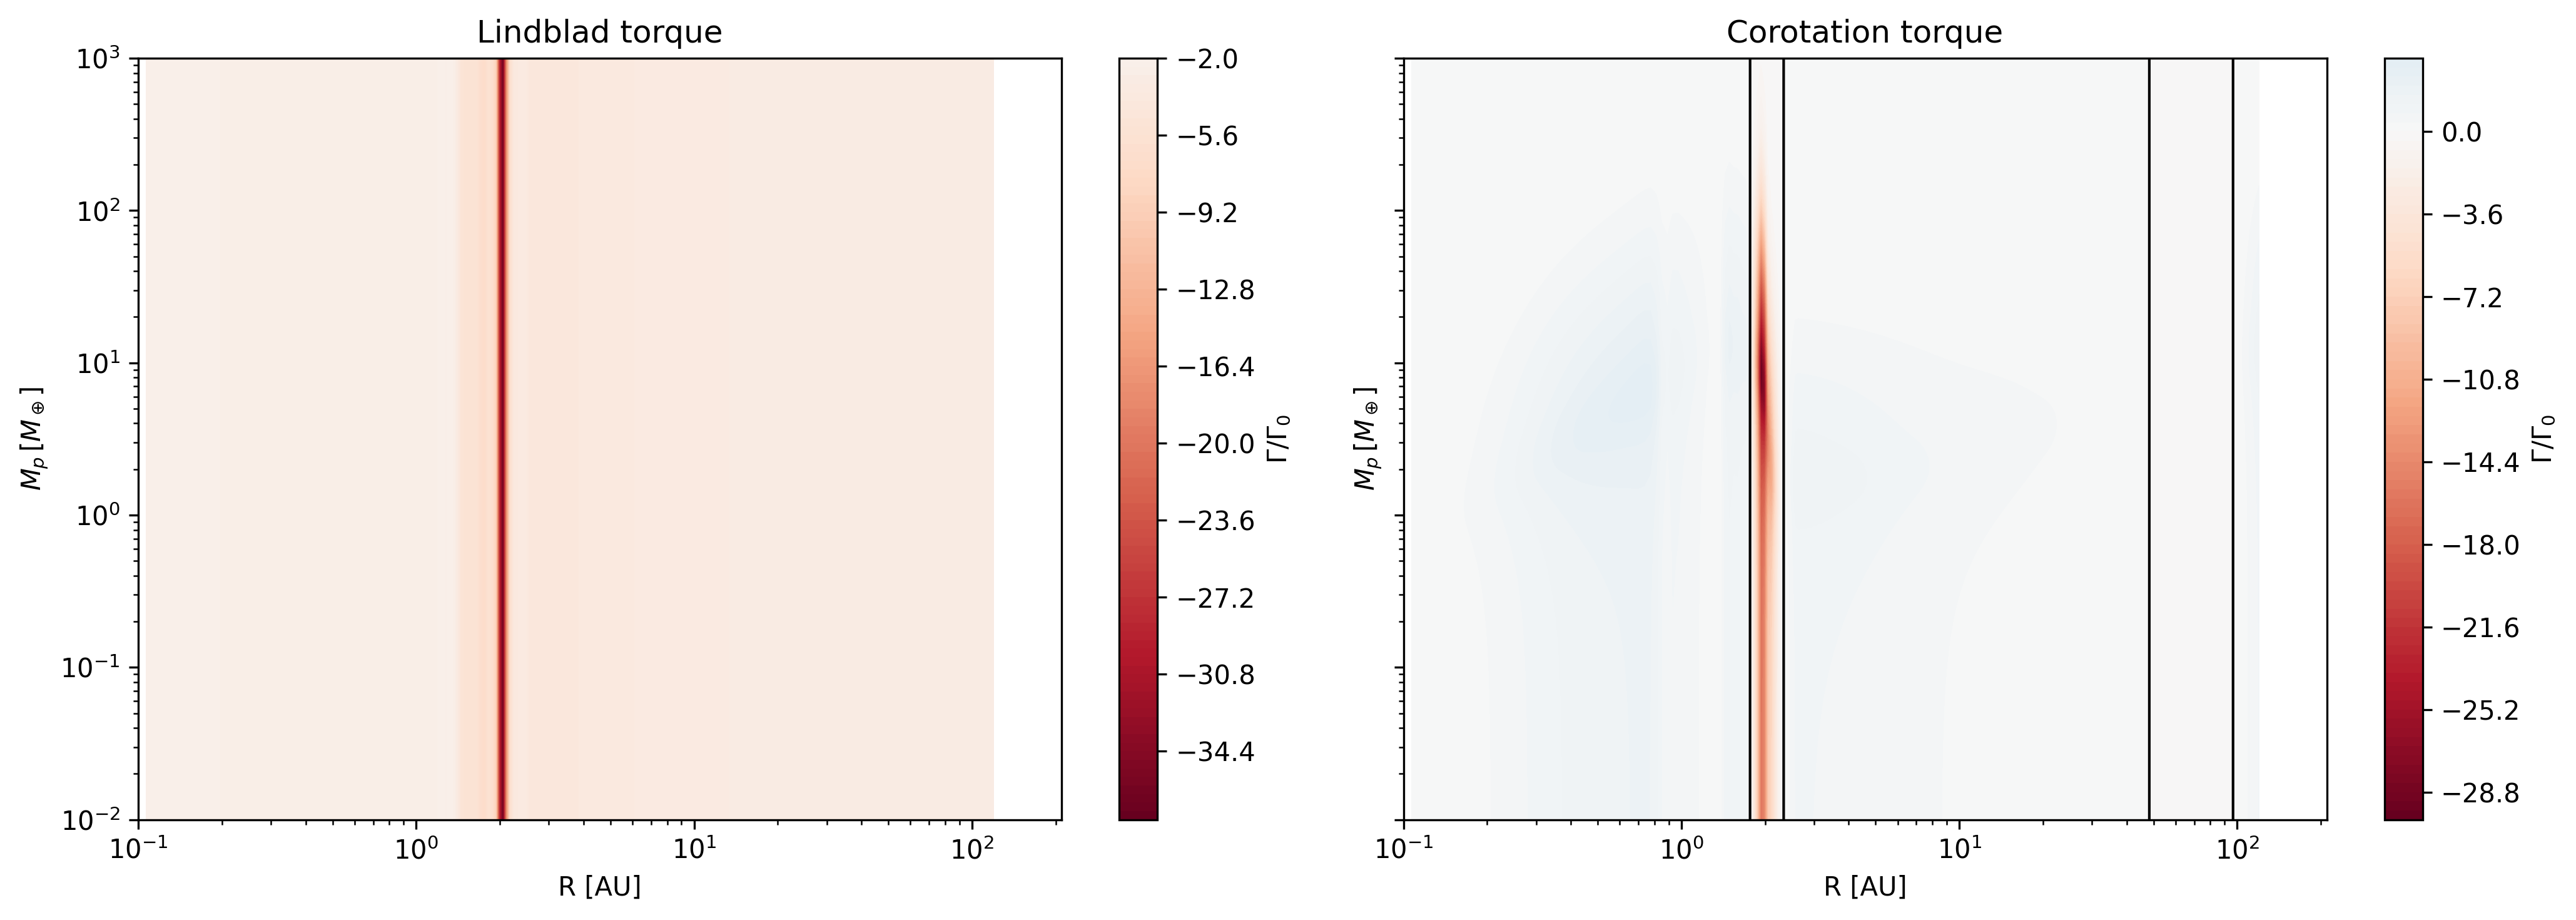

In [20]:
from matplotlib.colors import CenteredNorm
from matplotlib import colors
from DiscEvolution import planet_formation as pf

TypeI = pf.TypeIMigration(disc)

R_grid_1d = disc.R
M_grid_1d = np.logspace(-2, 3, Ncells)

GL = np.zeros((len(M_grid_1d), len(R_grid_1d)))
GC = np.zeros_like(GL)

for i, M in enumerate(M_grid_1d):
    GL[i], GC[i] = TypeI.compute_torque_components_raw(R_grid_1d, M)

R_grid, M_grid = np.meshgrid(R_grid_1d, M_grid_1d)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, title in zip(axes, [GL, GC], ['Lindblad', 'Corotation']):
    cmin = np.nanmin(data)
    cmax = np.nanmax(data)
    #norm = colors.TwoSlopeNorm(vmin=cmin, vcenter=0.0, vmax=cmax)
    norm = CenteredNorm()
    cp = ax.contourf(R_grid, M_grid, data, levels=100, cmap='RdBu', norm=norm)
    ax.contour(R_grid, M_grid, data, levels=[0.0], colors='black', linewidths=1.0)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('R [AU]'); ax.set_ylabel(r'$M_p\,[M_\oplus]$')
    ax.set_title(title + ' torque')
    ax.set_xlim(0.1, 210) 
    plt.colorbar(cp, ax=ax, label=r'$\Gamma / \Gamma_0$')

plt.tight_layout()
plt.show()

# Opacity Comparison to Speedie et Pudritz 

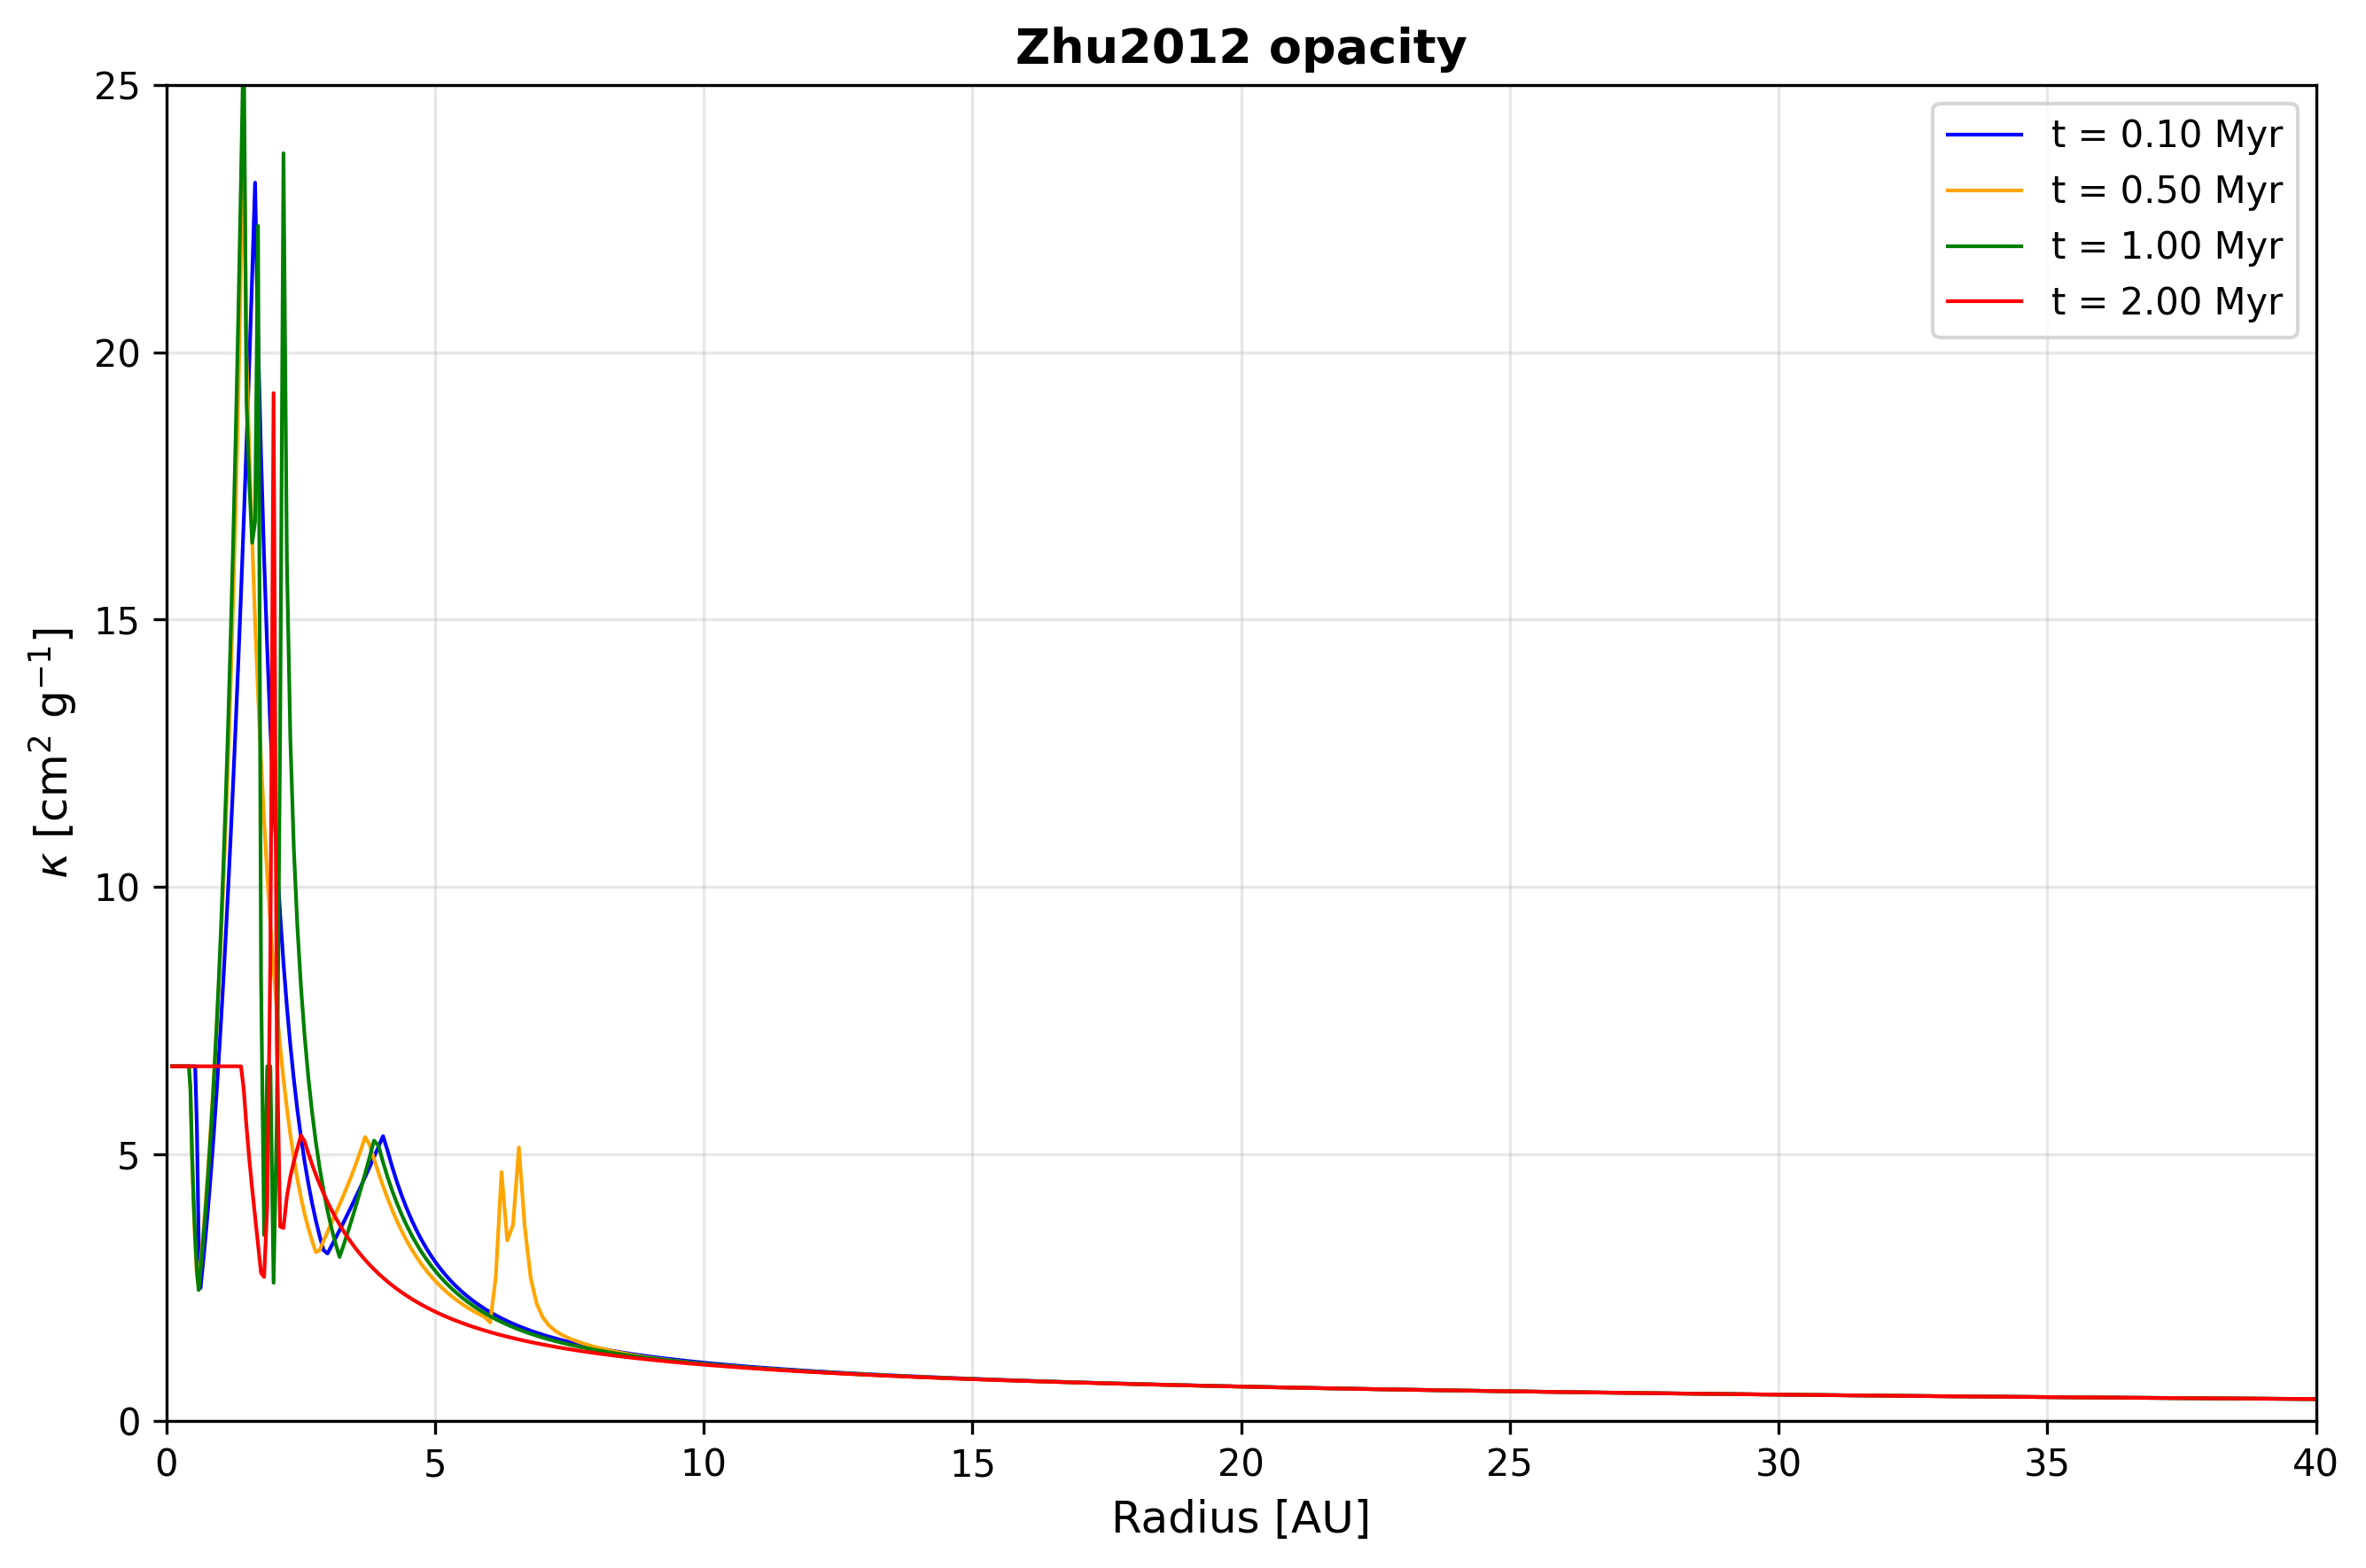

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_prop_cycle(ax_prop_cycle)

for i, t_yr in enumerate(snapshots['t_yr']):
    T_profile = snapshots['T'][i]
    rho_gas_mid = snapshots['mid_gas_dens'][i] 

    kappa = Zhu2012(rho_gas_mid, T_profile)
    ax.plot(disc.R, kappa, label=f't = {t_yr/1e6:.2f} Myr', lw=1)

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\kappa$ [cm$^2$ g$^{-1}$]', fontsize=12)
ax.set_title('Zhu2012 opacity', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0, 40)
ax.set_ylim(0,25)

plt.tight_layout()
#plt.savefig('output/zhu2012_HLtau.jpg', dpi=300)
plt.show()

# Alpha 

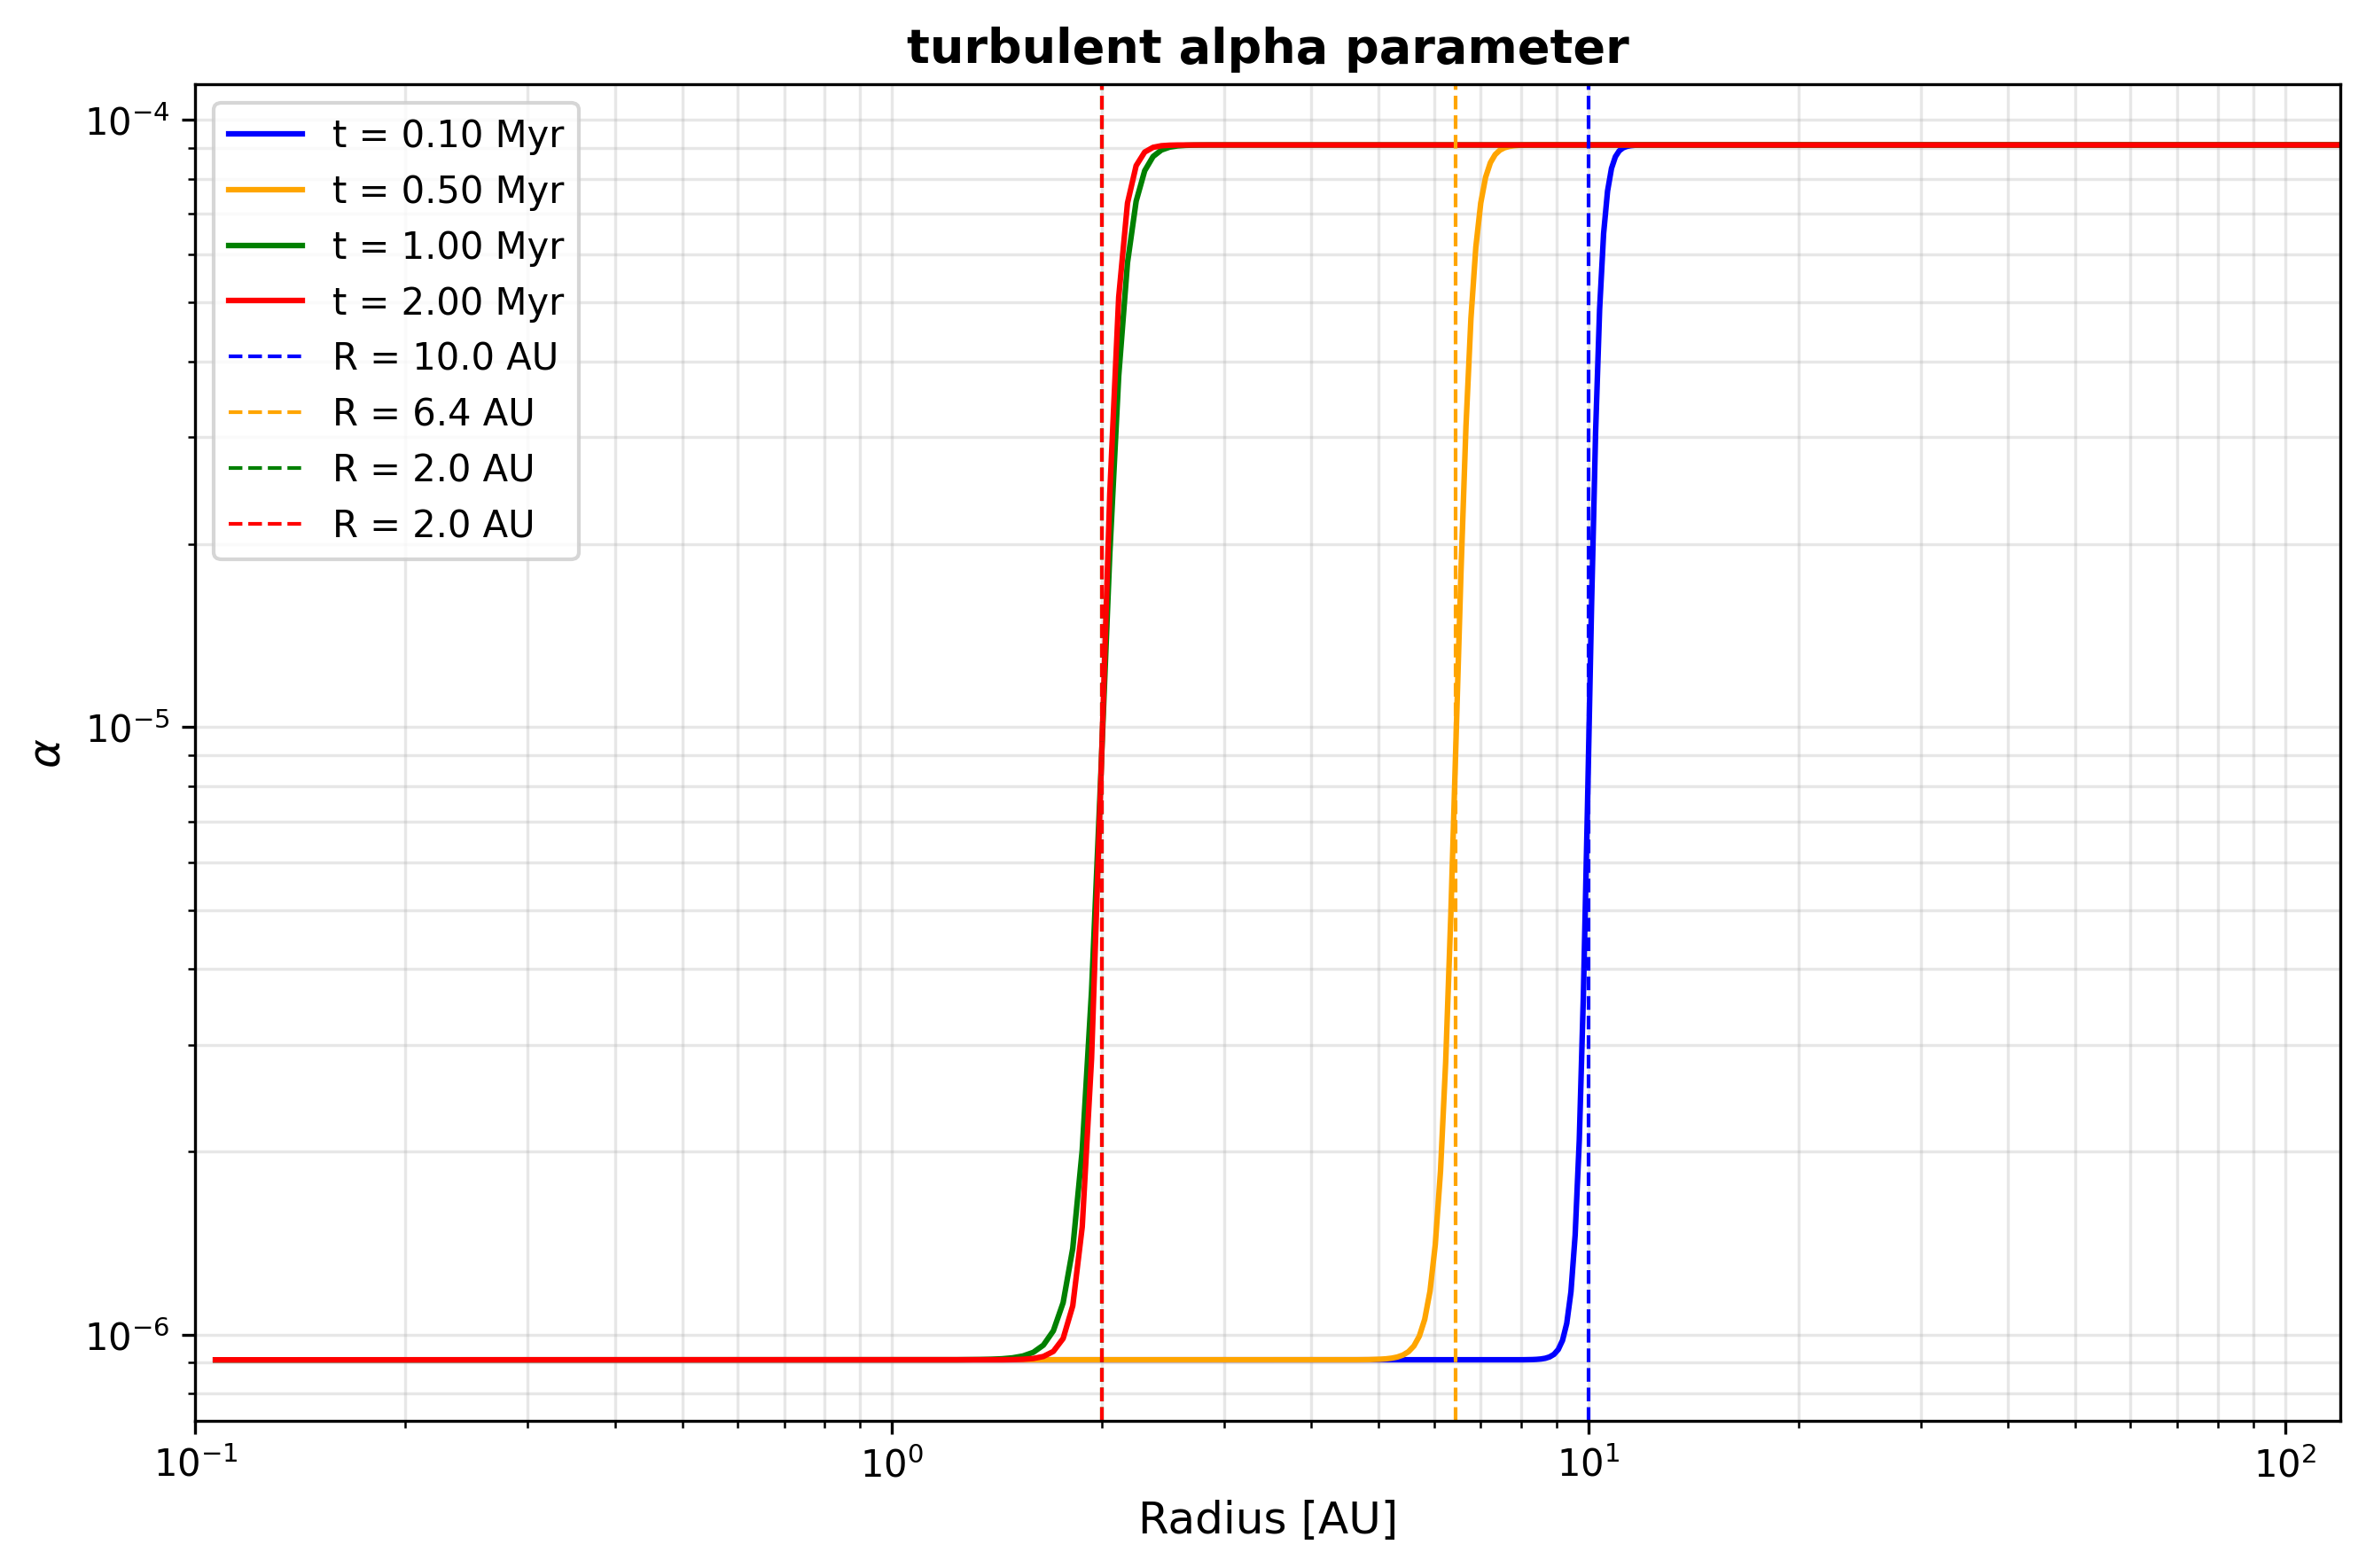

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_prop_cycle(ax_prop_cycle)

for i, t_yr in enumerate(snapshots['t_yr']):
    alpha = snapshots['alpha'][i]
    ax.loglog(disc.R, alpha, label=f't = {t_yr/1e6:.2f} Myr', lw=1.5)

colors = ax_prop_cycle.by_key()['color']
for i, t_yr in enumerate(snapshots['t_yr']):
    rdz = snapshots['rdz'][i]   
    ax.axvline(rdz, ls = 'dashed', lw=1.0, color=colors[i % len(colors)], label=f'R = {rdz:.1f} AU')

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\alpha$', fontsize=12)
ax.set_title(r'turbulent alpha parameter', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(R_in, R_out)
#ax.set_ylim(0,25)

plt.tight_layout()
plt.savefig('output/alpha_2H_width.jpg', dpi=300)
plt.show()

#TODO at inner radius you can see some jaggedness in the alpha line. Might cause issues. 

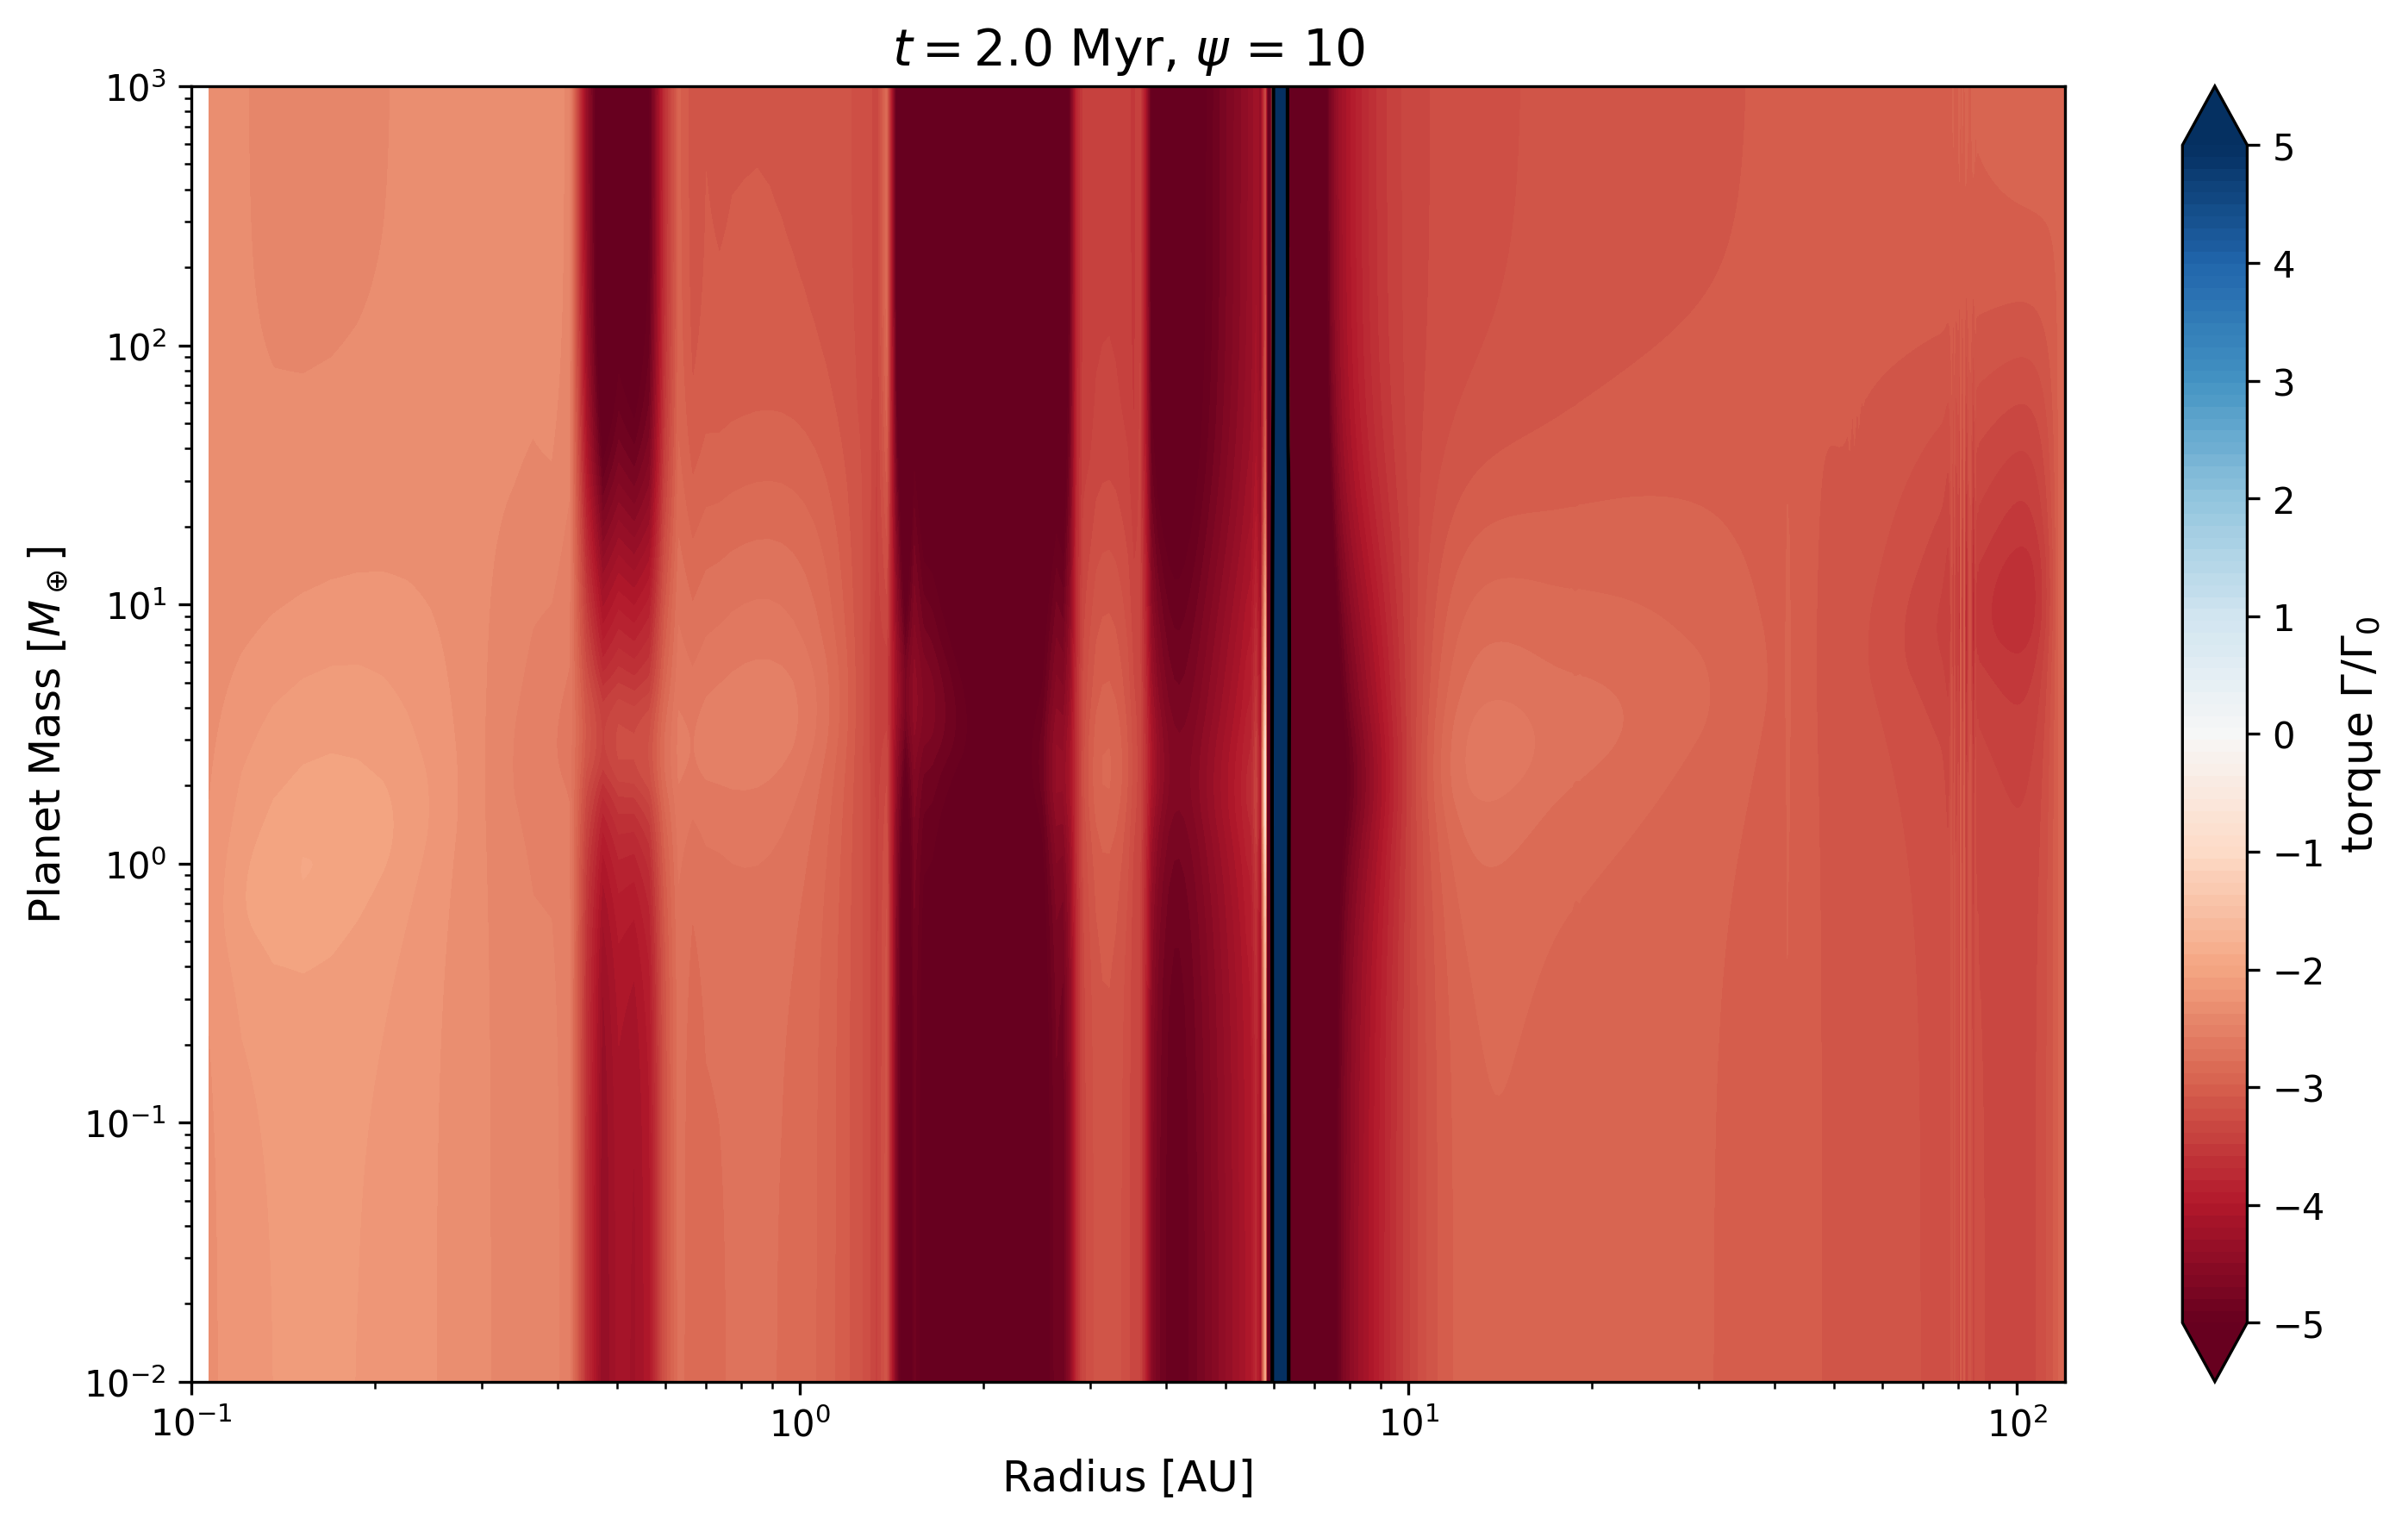

min: -42.811581348642605, max: 88.48486464727672


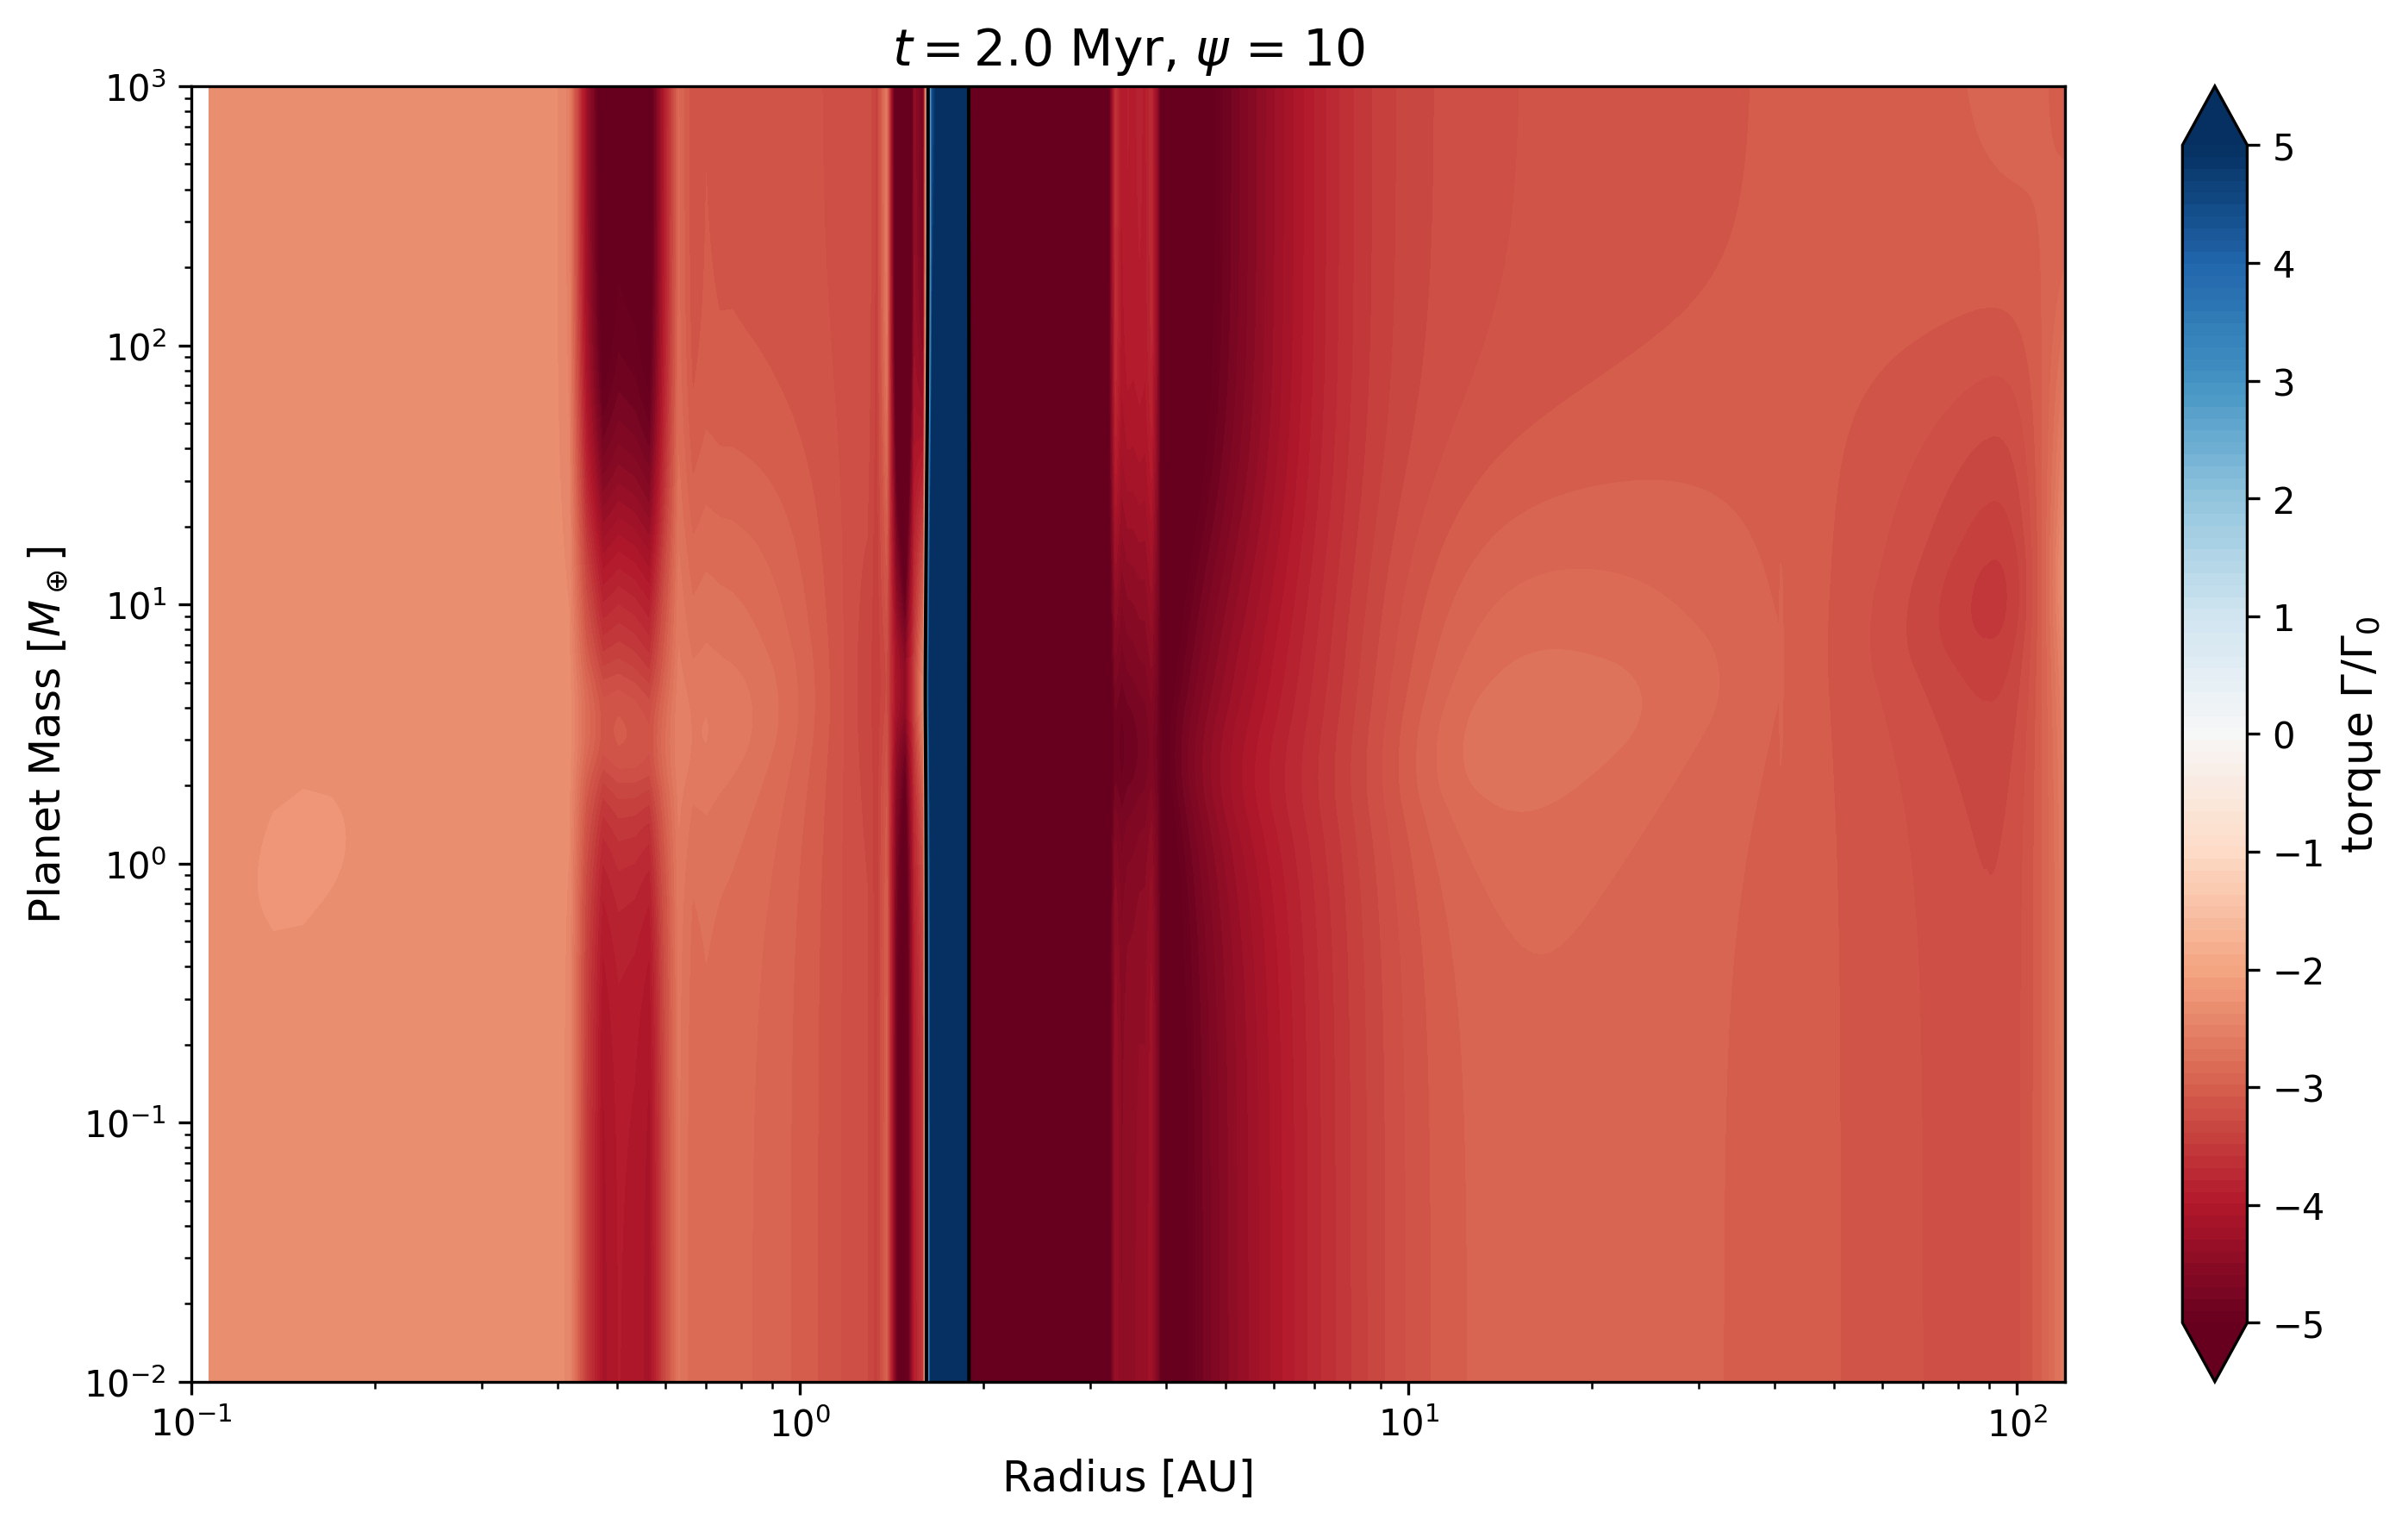

min: -40.08272999845388, max: 53.398475762958924


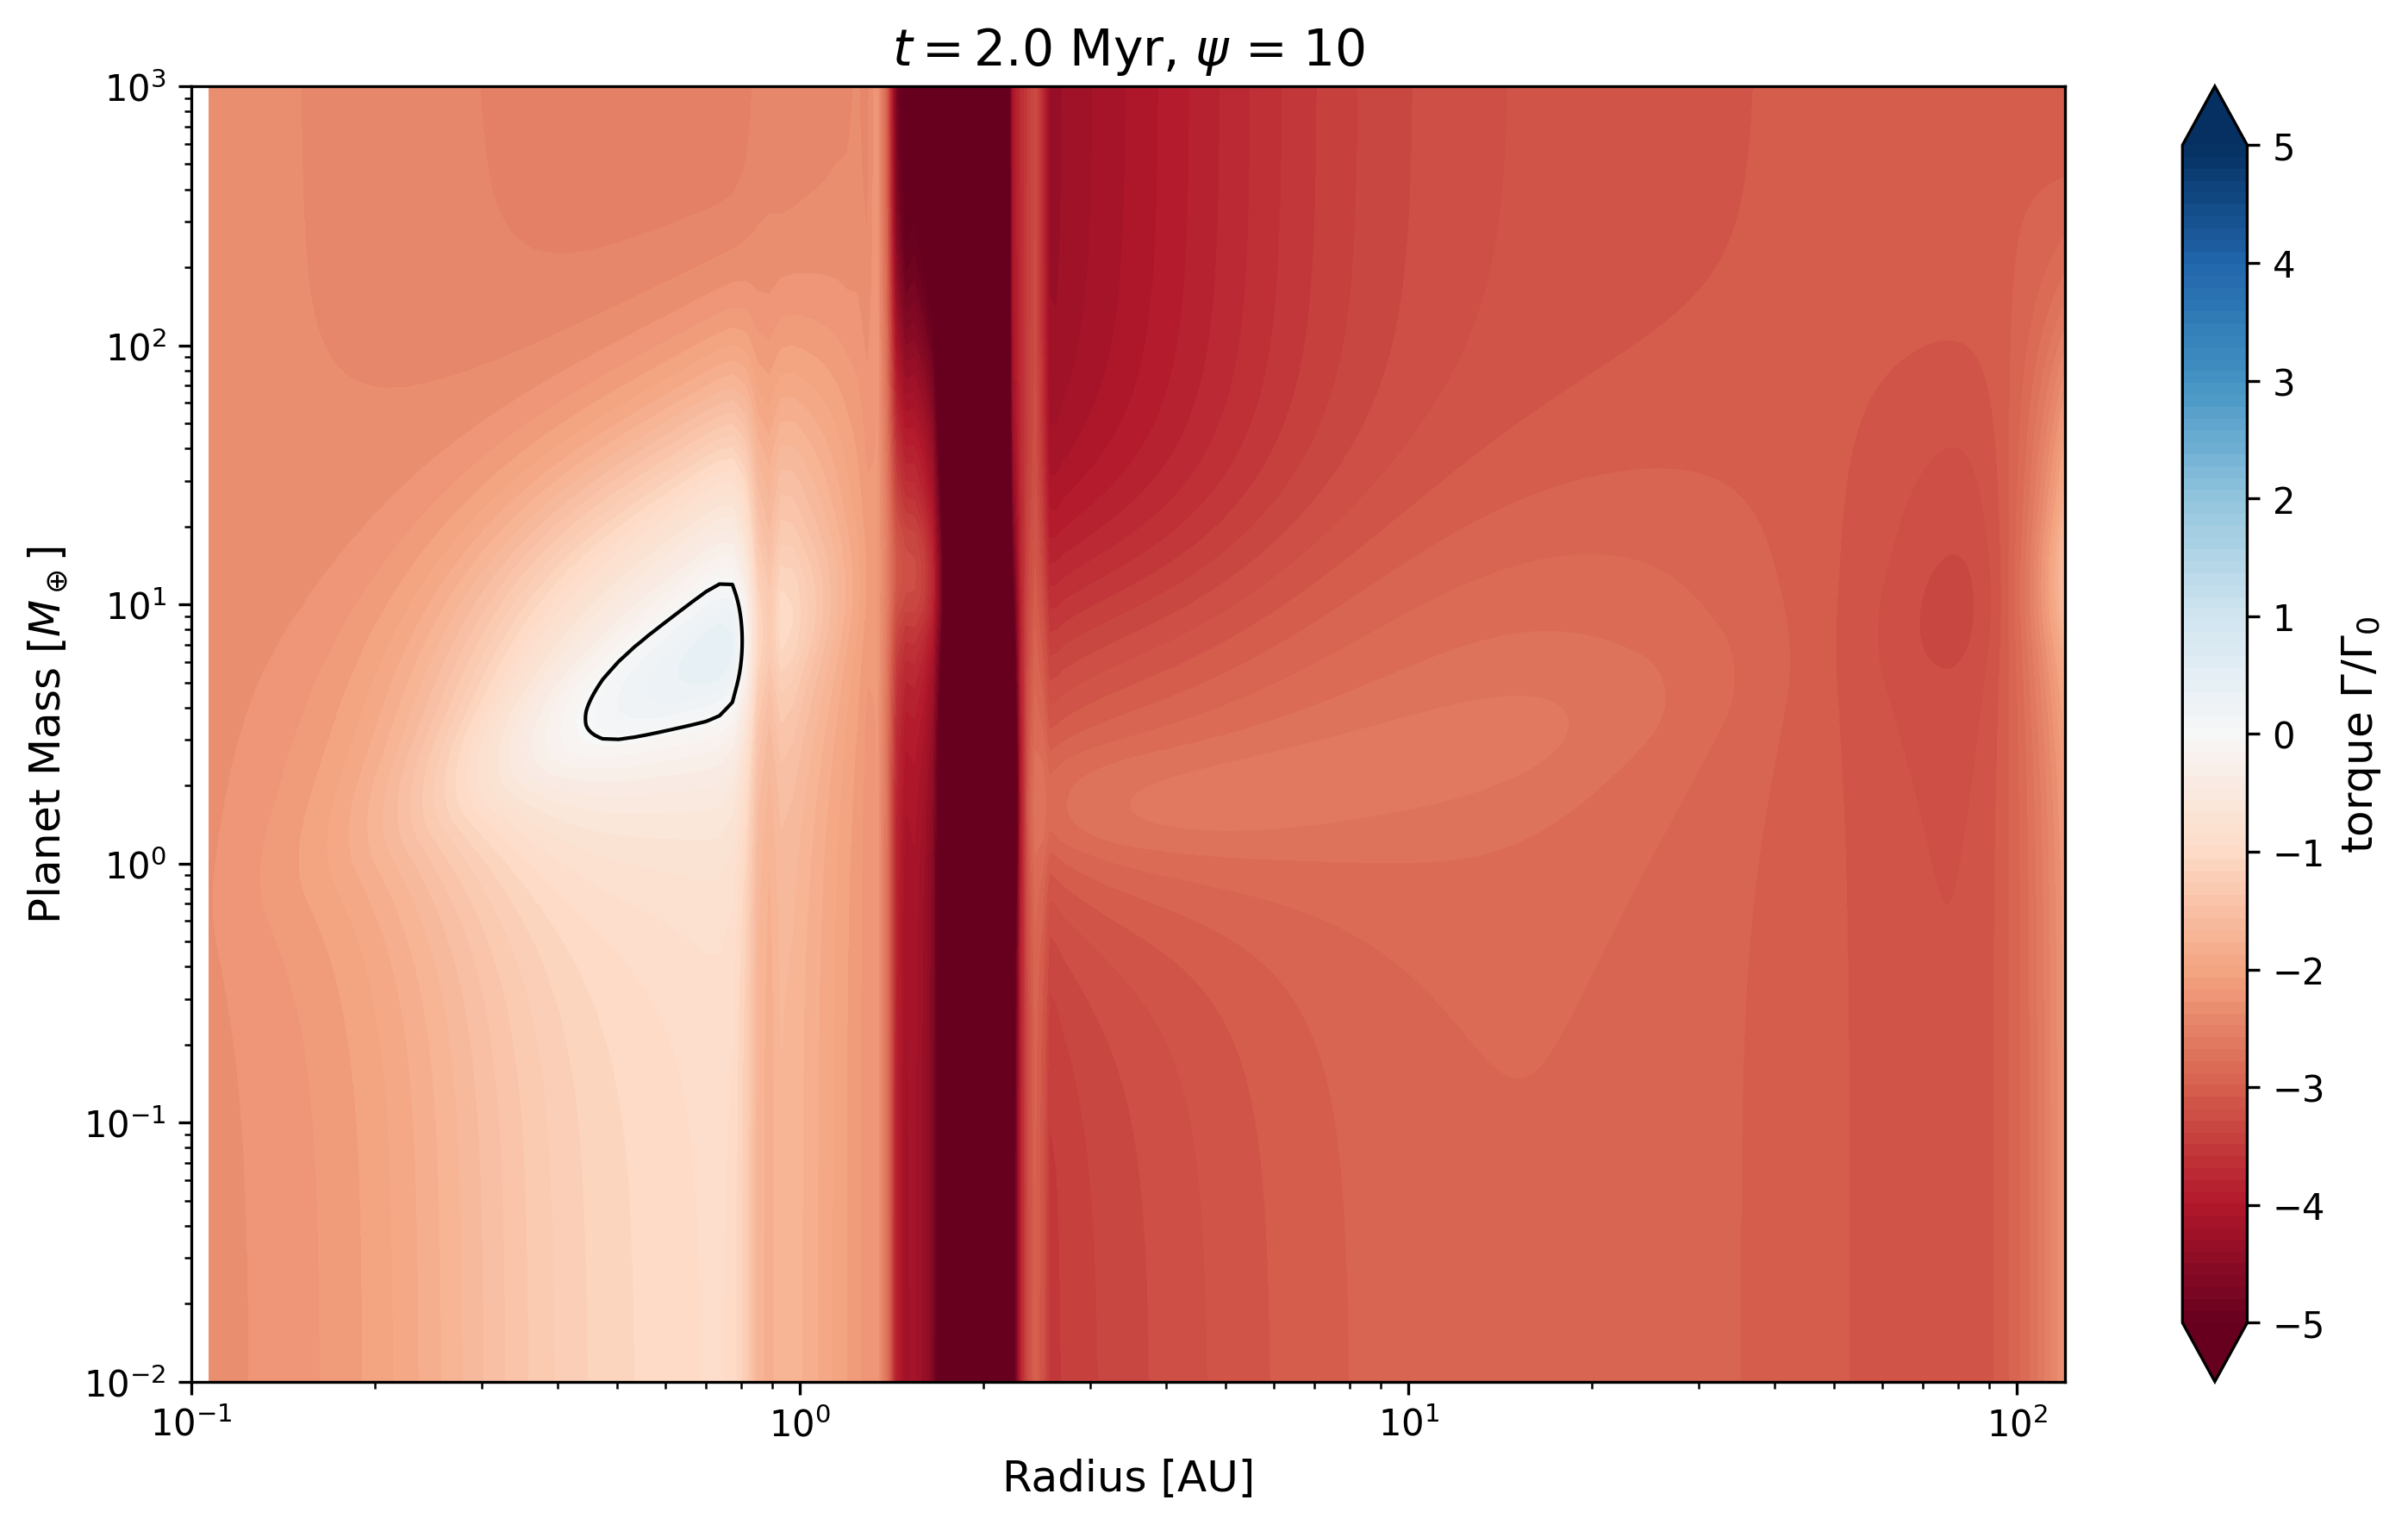

min: -56.834842320919265, max: 0.440610570485231


In [34]:
for tmap in torque_maps['maps']: 
    fig, ax = plt.subplots(figsize=(10, 6))

    # Colormap (Red = Inward/negative, Blue = Outward/Positive)
    norm = colors.TwoSlopeNorm(vmin=-5.0, vcenter=0.0, vmax=5.0)
    #norm = colors.CenteredNorm()
    symmetric_levels = np.linspace(-5.0, 5.0, 100) #Explicitly define 100 levels from -5 to +5
    cp = ax.contourf(R_grid, M_grid, tmap, levels=symmetric_levels, cmap='RdBu', norm=norm, extend='both')

    # Zero-Torque Planet Traps
    trap_lines = ax.contour(R_grid, M_grid, tmap, levels=[0.0], colors='black', linewidths=1.0)

    # Colorbar
    cbar = plt.colorbar(cp, ax=ax, ticks = np.arange(-5.0, 6.0, 1.0))
    cbar.set_label(rf'torque $\Gamma / \Gamma_0$', fontsize=12)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(R_in, R_out) 
    #ax.set_ylim(0.1, 100)

    ax.set_xlabel('Radius [AU]', fontsize=12)
    ax.set_ylabel(rf'Planet Mass [$M_\oplus$]', fontsize=12)
    ax.set_title(rf'$t = {driver.t / (1e6* 2 * np.pi)}$ Myr, $\psi$ = {disc._gas._psi}', fontsize=14)

    plt.tight_layout()
    #plt.savefig('output/TaboneZhu100-Torques.jpg', dpi=300)
    plt.show()
    print('min: '+str(float(np.min(tmap)))+', max: '+str(float(np.max(tmap))))